# Linear Attention ViT Pipeline for Particle Collision Images

**GSoC ML4SCI Project** -- Project-Requirement Aligned Notebook

This notebook is aligned to the required task flow:
1. **Pretrain Linear Attention ViT encoder** on unlabeled detector images using three SSL methods: **SimMIM, MAE, MAEv2**
2. **Save separate pretrained encoder weights** for each SSL method
3. **Fine-tune Linear Attention ViT** (low learning rate) from each pretrained encoder on labeled data
4. **Train the same Linear Attention ViT from scratch** under matched settings
5. **Compare SimMIM/MAE/MAEv2-pretrained vs scratch** using classification + regression metrics

Primary architecture for the required path:
- **Linear Attention ViT** -- ReLU/positive-kernel linear attention, O(N*d^2) in tokens

Secondary baselines (optional for broader benchmarking):
- Standard ViT, L2ViT, XCiT ViT

Architecture diagrams: `../images/`

---

### Changelog (Alignment + Stability)

| Change | Why |
|--------|-----|
| Requirement-first narrative (pretrain -> fine-tune -> scratch) | Matches project/mentor task description exactly |
| Linear-attention modular SSL classes in Section 5 | Keeps architecture and SSL implementation consistent |
| NaN-safe attention/loss guards | Prevents unstable pretraining loss explosions in notebook runs |
| Backward-compatible class aliases (`*Pretrainer`) | Keeps existing training/eval code unchanged |
| Existing loops/data/eval left untouched | Preserves reproducibility of your original workflow |

**How to run:**
- **Quick sanity test:** Set `RUN_MODE = "debug"` in Section 1, then Run All.
- **Full required experiment:** Set `RUN_MODE = "full"`, run Section 9 -> Section 10 -> Section 11.
- **Reporting:** Use benchmark and summary sections to compare SimMIM/MAE/MAEv2-pretrained vs scratch and baselines.

## Section 1: Configuration

In [20]:

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

RUN_MODE = "full"

STRICT_DETERMINISM = False


IMG_SIZE = 64                                  
PATCH_SIZE = 8                                      
IN_CHANS = 8                                                       
EMBED_DIM = 256                                         
DEPTH = 10                                           
NUM_HEADS = 8                                     
MLP_RATIO = 4.0                              
DROPOUT = 0.1                               

BATCH_SIZE = 32
EPOCHS = 35
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_FRAC = 0.80                             
SEED = 42
LAMBDA_REG = 0.2                                                                            
REGRESSION_LAMBDA = LAMBDA_REG                         
GRAD_CLIP_NORM = 1.0                                   

USE_HUBER_LOSS = False                                                            

USE_AMP = False                                                                         
USE_EMA = False                                                      

ES_PATIENCE = 7                                                      

TWO_PHASE_TRAINING = False
PHASE_A_EPOCHS = 5                                                             
PHASE_A_LAMBDA = 0.0                                      

LOG_EVERY_N_BATCHES = 50                                                  

PRETRAIN_EPOCHS = 20
MASK_RATIO = 0.50
LR_PRETRAIN = 1e-3

DATA_DIR = Path(r"C:\Users\Rahul\Desktop\AA Gsoc'26\data")
UNLABELED_FILE = DATA_DIR / "Dataset_Specific_Unlabelled.h5"
LABELED_FILE = DATA_DIR / "Dataset_Specific_labelled_full_only_for_2i.h5"

NUM_CLASSES = 2                                                

DL_NUM_WORKERS = 0
DL_PIN_MEMORY = False

MULTI_SEEDS = [42, 52, 62]


def get_device() -> torch.device:
    """Auto-detect the best available compute device."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Using device: {DEVICE}", flush=True)
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}", flush=True)
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB", flush=True)



def seed_everything(seed: int = 42) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if STRICT_DETERMINISM:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)


seed_everything(SEED)
print(f"Seeds set to {SEED} | STRICT_DETERMINISM={STRICT_DETERMINISM}", flush=True)
print(f"RUN_MODE={RUN_MODE} | EPOCHS={EPOCHS} | PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}", flush=True)
print(f"BATCH_SIZE={BATCH_SIZE} | LR={LR} | WEIGHT_DECAY={WEIGHT_DECAY}", flush=True)
print(f"LAMBDA_REG={LAMBDA_REG} | USE_AMP={USE_AMP} | USE_EMA={USE_EMA}", flush=True)
print(f"PyTorch version: {torch.__version__}", flush=True)



Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.4 GB
Seeds set to 42 | STRICT_DETERMINISM=False
RUN_MODE=full | EPOCHS=35 | PRETRAIN_EPOCHS=20
BATCH_SIZE=32 | LR=0.0003 | WEIGHT_DECAY=0.0001
LAMBDA_REG=0.2 | USE_AMP=False | USE_EMA=False
PyTorch version: 2.3.0+cu121


## Section 2: Dataset Loading

In [21]:

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset


def inspect_hdf5(filepath: str) -> None:
    """Print HDF5 structure, shapes, dtypes, and sample unique values for 1D datasets."""
    print(f"\n=== HDF5 File: {filepath} ===")
    with h5py.File(filepath, "r") as f:
        def _print_tree(name, obj):
            indent = "  " * name.count("/")
            if hasattr(obj, "shape"):
                msg = f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}"
                if len(obj.shape) == 1 and obj.shape[0] > 0:
                    sample = np.asarray(obj[: min(50, obj.shape[0])]).reshape(-1)
                    msg += f", sample_unique={np.unique(sample)}"
                print(msg)
            else:
                print(f"{indent}{name}/")
        f.visititems(_print_tree)


class LazyHDF5Dataset(Dataset):
    """
    Lazy-loading HDF5 dataset for particle collision images.
    Requires valid keys for labeled data (mass + label).
    """

    def __init__(
        self,
        filepath,
        labeled: bool = True,
        transform=None,
        img_key: str = None,
        mass_key: str = None,
        label_key: str = None,
    ):
        self.filepath = str(filepath)
        self.labeled = labeled
        self.transform = transform
        self._file = None               

        with h5py.File(self.filepath, "r") as f:
            keys = list(f.keys())

            if img_key is not None:
                if img_key not in keys:
                    raise ValueError(f"img_key='{img_key}' not found. Available keys: {keys}")
                self.img_key = img_key
            else:
                preferred_img = ["jet", "X", "images", "image", "data", "X_jets", "jet_images", "jets"]
                self.img_key = None
                for k in preferred_img:
                    if k in keys and hasattr(f[k], "shape") and len(f[k].shape) >= 3:
                        self.img_key = k
                        break
                if self.img_key is None:
                    for k in keys:
                        obj = f[k]
                        if hasattr(obj, "shape") and len(obj.shape) >= 3 and obj.shape[0] > 1:
                            self.img_key = k
                            break
                if self.img_key is None:
                    raise ValueError(f"No image-like key found in {self.filepath}. Keys={keys}")

            self.length = int(f[self.img_key].shape[0])

            self.mass_key = None
            self.label_key = None

            if self.labeled:
                if mass_key is not None:
                    if mass_key not in keys:
                        raise ValueError(f"mass_key='{mass_key}' not found. Available keys: {keys}")
                    self.mass_key = mass_key
                else:
                    for k in ["m", "mass", "m0", "y_mass", "target_mass"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.mass_key = k
                            break
                    if self.mass_key is None:
                        raise ValueError(
                            f"Could not infer mass_key. Please pass it explicitly. Available keys: {keys}"
                        )

                if label_key is not None:
                    if label_key not in keys:
                        raise ValueError(f"label_key='{label_key}' not found. Available keys: {keys}")
                    self.label_key = label_key
                else:
                    for k in ["label", "labels", "y", "cls", "class", "target", "pid"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.label_key = k
                            break
                    if self.label_key is None:
                        for k in keys:
                            if k == self.mass_key:
                                continue
                            obj = f[k]
                            if hasattr(obj, "shape") and len(obj.shape) == 1 and obj.shape[0] == self.length:
                                if np.issubdtype(obj.dtype, np.integer):
                                    self.label_key = k
                                    break

                    if self.label_key is None:
                        raise ValueError(
                            f"Could not infer label_key. Please pass it explicitly. Available keys: {keys}"
                        )

        print(f"[LazyHDF5Dataset] file={self.filepath}")
        print(f"  img_key={self.img_key}")
        if self.labeled:
            print(f"  mass_key={self.mass_key}, label_key={self.label_key}")

    def _get_file(self):
        if self._file is None or not self._file.id.valid:
            self._file = h5py.File(self.filepath, "r")
        return self._file

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        f = self._get_file()

        img = np.array(f[self.img_key][idx], dtype=np.float32)
        img = torch.from_numpy(img)

        if img.ndim == 2:
            img = img.unsqueeze(0)           
        elif img.ndim == 3:
            if img.shape[-1] <= 16 and img.shape[0] > 16 and img.shape[1] > 16:
                img = img.permute(2, 0, 1)

        if self.transform is not None:
            img = self.transform(img)

        if self.labeled:
            mass = float(f[self.mass_key][idx])
            label = int(f[self.label_key][idx])
            return img, torch.tensor(mass, dtype=torch.float32), torch.tensor(label, dtype=torch.long)
        else:
            return (img,)

    def __del__(self):
        if self._file is not None and self._file.id.valid:
            self._file.close()



print("\n--- Loading Datasets (HDF5 only) ---")

if not LABELED_FILE.exists():
    raise FileNotFoundError(f"Labeled HDF5 file not found: {LABELED_FILE}")
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

print(f"Found labeled file: {LABELED_FILE}")
inspect_hdf5(str(LABELED_FILE))

print(f"\nFound unlabeled file: {UNLABELED_FILE}")
inspect_hdf5(str(UNLABELED_FILE))

LABELED_IMG_KEY = "jet"
LABELED_MASS_KEY = "m"
LABELED_LABEL_KEY = "Y"
UNLABELED_IMG_KEY = "jet"

raw_dataset = LazyHDF5Dataset(
    LABELED_FILE,
    labeled=True,
    img_key=LABELED_IMG_KEY,
    mass_key=LABELED_MASS_KEY,
    label_key=LABELED_LABEL_KEY,
)
unlabeled_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key=UNLABELED_IMG_KEY,
)

print(f"\nLabeled dataset size: {len(raw_dataset)}")
print(f"Unlabeled dataset size: {len(unlabeled_dataset_raw)}")
print("USING_SYNTHETIC = False")
USING_SYNTHETIC = False


--- Loading Datasets (HDF5 only) ---
Found labeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5 ===
Y: shape=(10000, 1), dtype=float32
jet: shape=(10000, 125, 125, 8), dtype=float32
m: shape=(10000, 1), dtype=float32
pT: shape=(10000, 1), dtype=float32

Found unlabeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5 ===
jet: shape=(60000, 125, 125, 8), dtype=float32
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5
  img_key=jet
  mass_key=m, label_key=Y
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet

Labeled dataset size: 10000
Unlabeled dataset size: 60000
USING_SYNTHETIC = False


## Section 3: Data Preprocessing & Augmentation

Train samples: 8000 | Val samples: 2000
Label distribution (full):  Counter({0: 5122, 1: 4878})
Label distribution (train): Counter({0: 4107, 1: 3893})
Label distribution (val):   Counter({0: 1015, 1: 985})
Mass normalization: mean=142.4647, std=50.5794
Train batches: 250 | Val batches: 63

--- Unlabeled samples (log-compressed, ch 0) ---


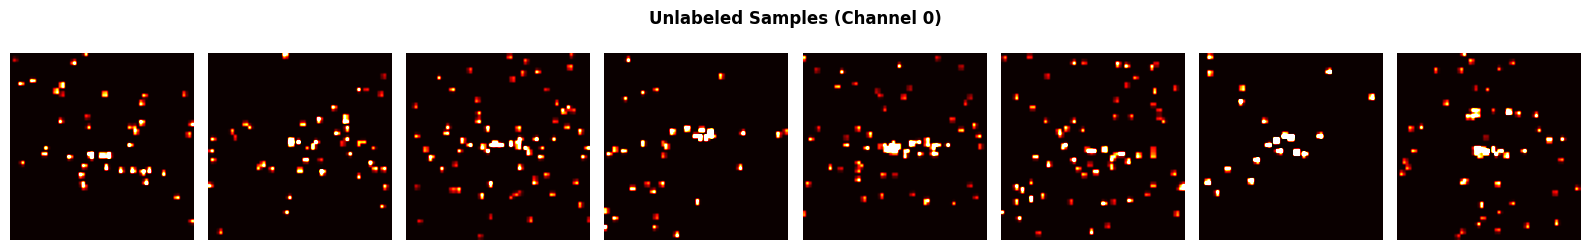


--- Labeled validation samples (log-compressed, ch 0) ---


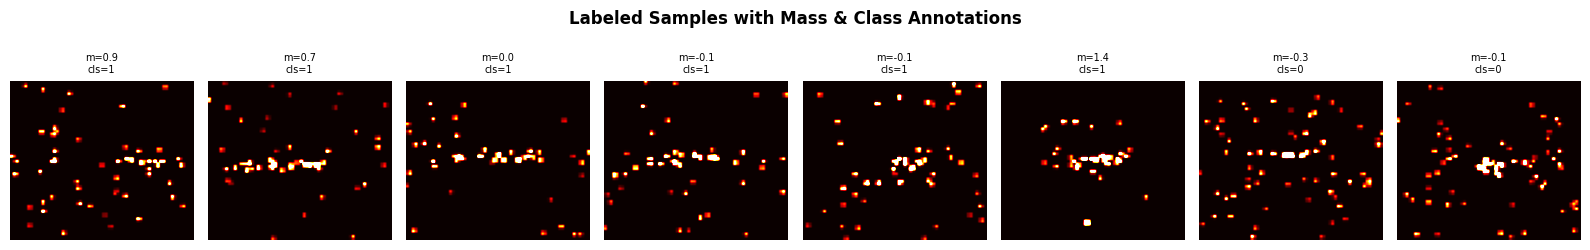

In [22]:

import math
import random
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt



class PhysicsPreprocess(nn.Module):
    """Physics-inspired preprocessing for detector images."""

    def __init__(self, img_size: int = 64, in_chans: int = 8, allow_fallback_zeros: bool = True):
        super().__init__()
        self.img_size = int(img_size)
        self.in_chans = int(in_chans)
        self.allow_fallback_zeros = allow_fallback_zeros

        y_coords, x_coords = torch.meshgrid(
            torch.arange(self.img_size, dtype=torch.float32),
            torch.arange(self.img_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("x_coords", x_coords, persistent=False)
        self.register_buffer("y_coords", y_coords, persistent=False)

    def _fallback_image(self, device, dtype):
        return torch.zeros((self.in_chans, self.img_size, self.img_size), device=device, dtype=dtype)

    def _to_chw(self, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(x):
            x = torch.as_tensor(x)
        x = x.float()

        if x.ndim == 0:
            if self.allow_fallback_zeros:
                warnings.warn("PhysicsPreprocess: scalar input encountered; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Expected image-like tensor, got scalar: {x}")

        if x.ndim == 1 and x.numel() <= 1:
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: tiny 1D input shape={tuple(x.shape)}; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Tiny 1D tensor cannot represent image: shape={tuple(x.shape)}")

        if x.ndim == 1:
            n = x.numel()
            if n % self.in_chans == 0:
                hw = n // self.in_chans
                h = int(math.isqrt(hw))
                if h * h == hw:
                    return x.view(self.in_chans, h, h)
            h = int(math.isqrt(n))
            if h * h == n:
                return x.view(1, h, h)
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: cannot infer image shape from flattened length={n}; fallback zeros.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Cannot infer image shape from flattened tensor length={n}")

        if x.ndim == 2:
            return x.unsqueeze(0)

        if x.ndim == 3:
            if x.shape[-1] <= 16 and x.shape[0] > 16 and x.shape[1] > 16:
                return x.permute(2, 0, 1)
            return x

        if self.allow_fallback_zeros:
            warnings.warn(f"PhysicsPreprocess: unsupported ndim={x.ndim}, shape={tuple(x.shape)}; fallback zeros.")
            return self._fallback_image(x.device, x.dtype)
        raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

    def energy_center_align(self, x: torch.Tensor) -> torch.Tensor:
        c, h, w = x.shape

        energy = x.sum(dim=0)
        total_energy = energy.sum()
        if total_energy.abs() < 1e-6:
            return x

        if h == self.img_size and w == self.img_size:
            x_coords = self.x_coords
            y_coords = self.y_coords
        else:
            y_coords, x_coords = torch.meshgrid(
                torch.arange(h, device=x.device, dtype=torch.float32),
                torch.arange(w, device=x.device, dtype=torch.float32),
                indexing="ij",
            )

        cx = (energy * x_coords).sum() / total_energy
        cy = (energy * y_coords).sum() / total_energy

        shift_x = int((w // 2) - cx.item())
        shift_y = int((h // 2) - cy.item())

        x = torch.roll(x, shifts=(shift_y, shift_x), dims=(1, 2))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._to_chw(x)

        x = torch.log1p(x.clamp(min=0.0))                                  
        x = torch.where(x < 1e-3, torch.zeros_like(x), x)                    
        x = self.energy_center_align(x)                                        

        if x.shape[-2] != self.img_size or x.shape[-1] != self.img_size:
            x = TF.resize(x, [self.img_size, self.img_size], antialias=True)

        c = x.shape[0]
        if c < self.in_chans:
            repeats = (self.in_chans + c - 1) // c
            x = x.repeat(repeats, 1, 1)[: self.in_chans]
        elif c > self.in_chans:
            x = x[: self.in_chans]

        x = x / (x.sum() + 1e-8)                       

        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)

        return x



class AugmentTransform(nn.Module):
    """Physics-safe data augmentation."""
    def __init__(self, p: float = 0.25, noise_std: float = 0.01):
        super().__init__()
        self.p = float(p)
        self.noise_std = float(noise_std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < self.p:
            x = TF.hflip(x)

        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.noise_std

        if random.random() < self.p:
            x = x * (0.9 + 0.2 * random.random())

        if random.random() < self.p:
            _, h, w = x.shape
            patch_size = random.randint(2, 4)
            y0 = random.randint(0, max(0, h - patch_size))
            x0 = random.randint(0, max(0, w - patch_size))
            x[:, y0:y0 + patch_size, x0:x0 + patch_size] = 0.0

        return x


class TrainTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)
        self.augment = AugmentTransform()

    def forward(self, x):
        return self.augment(self.preprocess(x))


class ValTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)

    def forward(self, x):
        return self.preprocess(x)


class TransformedDataset(Dataset):
    """Wraps base dataset + transform on image only."""
    def __init__(self, base_dataset: Dataset, transform=None, mass_mean: float = None, mass_std: float = None):
        self.base = base_dataset
        self.transform = transform
        self.mass_mean = mass_mean
        self.mass_std = mass_std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]                      
        img = self.transform(item[0]) if self.transform is not None else item[0]

        if len(item) >= 3:
            mass = torch.as_tensor(item[1]).view(-1)[0].to(torch.float32)
            label = torch.as_tensor(item[2]).view(-1)[0].to(torch.long)

            if self.mass_mean is not None and self.mass_std is not None:
                denom = self.mass_std if abs(float(self.mass_std)) > 1e-12 else 1.0
                mass = (mass - float(self.mass_mean)) / float(denom)

            return img, mass, label

        return (img,) + item[1:]


def compute_mass_stats(dataset):
    masses = []
    for i in range(len(dataset)):
        item = dataset[i]
        if len(item) >= 2:
            m = torch.as_tensor(item[1]).view(-1)[0].item()
            masses.append(float(m))
    if len(masses) == 0:
        return 0.0, 1.0
    masses = torch.tensor(masses, dtype=torch.float32)
    std = masses.std().item()
    if std < 1e-12:
        std = 1.0
    return masses.mean().item(), std


def get_label_dist(dataset):
    cnt = Counter()
    for i in range(len(dataset)):
        y = dataset[i][2]
        y = int(torch.as_tensor(y).view(-1)[0].item())
        cnt[y] += 1
    return cnt


n_total = len(raw_dataset)
n_train = int(n_total * TRAIN_FRAC)
n_val = n_total - n_train
generator = torch.Generator().manual_seed(SEED)
train_raw, val_raw = random_split(raw_dataset, [n_train, n_val], generator=generator)

print(f"Train samples: {n_train} | Val samples: {n_val}")

dist_all = get_label_dist(raw_dataset)
dist_train = get_label_dist(train_raw)
dist_val = get_label_dist(val_raw)

print("Label distribution (full): ", dist_all)
print("Label distribution (train):", dist_train)
print("Label distribution (val):  ", dist_val)

if len(dist_all) < 2:
    raise RuntimeError(
        "Only one class detected in labeled dataset. Recheck Section 2 label_key (should be 'Y' for your file)."
    )

MASS_MEAN, MASS_STD = compute_mass_stats(train_raw)
print(f"Mass normalization: mean={MASS_MEAN:.4f}, std={MASS_STD:.4f}")

train_dataset = TransformedDataset(train_raw, TrainTransform(IMG_SIZE, IN_CHANS), mass_mean=MASS_MEAN, mass_std=MASS_STD)
val_dataset = TransformedDataset(val_raw, ValTransform(IMG_SIZE, IN_CHANS), mass_mean=MASS_MEAN, mass_std=MASS_STD)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


def plot_sample_images_raw(dataset: Dataset, n: int = 8, title: str = "Sample Images") -> None:
    n = min(n, len(dataset))
    if n == 0:
        print("Dataset is empty.")
        return

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]

    shown, i = 0, 0
    while shown < n and i < len(dataset):
        ax = axes[shown]
        try:
            item = dataset[i]
            img = item[0]
            if img.ndim == 3:
                img = img[0]
            arr = img.detach().cpu().numpy()

            vmin = np.percentile(arr, 1)
            vmax = np.percentile(arr, 99)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
                vmin, vmax = None, None

            ax.imshow(arr, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
            ax.axis("off")

            if len(item) >= 3:
                mass = float(torch.as_tensor(item[1]).view(-1)[0].item())
                label = int(torch.as_tensor(item[2]).view(-1)[0].item())
                ax.set_title(f"m={mass:.1f}\ncls={label}", fontsize=7)

            shown += 1
        except Exception:
            pass
        i += 1

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("\n--- Unlabeled samples (log-compressed, ch 0) ---")
unlabeled_vis = TransformedDataset(unlabeled_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
plot_sample_images_raw(unlabeled_vis, n=min(8, len(unlabeled_vis)), title="Unlabeled Samples (Channel 0)")

print("\n--- Labeled validation samples (log-compressed, ch 0) ---")
plot_sample_images_raw(val_dataset, n=min(8, len(val_dataset)), title="Labeled Samples with Mass & Class Annotations")

## Section 4: Model Architectures

Four core architectures for benchmarking:
- **StandardViT**: quadratic self-attention baseline O(N^2*d)
- **LinearAttentionViT**: ReLU kernel linear attention O(N*d^2)
- **L2ViT**: Linear Global Attention + Local Window Attention (hybrid)
- **XCiTViT**: Cross-Covariance Attention O(N*d^2) (El-Nouby et al.)

Modular design allows swapping attention mechanisms easily.

In [23]:

import math
from functools import partial

import torch.nn.functional as F



class DropPath(nn.Module):
    """Stochastic Depth (Drop Path) regularization.
    Reference: Huang et al., 2016."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class PatchEmbed(nn.Module):
    """Image-to-patch embedding using Conv2D.
    Input: B x C x H x W -> Output: B x N x D
    Includes positional encoding via learnable embeddings."""

    def __init__(self, img_size=64, patch_size=8, in_chans=8, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)                                            
        x = x.flatten(2).transpose(1, 2)                     
        return x


class MLP(nn.Module):
    """Two-layer FFN with GELU activation and dropout."""

    def __init__(self, in_features: int, hidden_features: int = None, dropout: float = 0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def _make_cls_head(in_dim: int, out_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Two-layer classification head."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, out_dim),
    )


def _make_reg_head(in_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Deeper 3-layer regression head for improved mass prediction."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, in_dim // 4),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 4, 1),
)

class RegressionHead(nn.Module):
    """Deeper MLP regression head for mass prediction.

    Accepts concatenated CLS + mean token features (embed_dim * 2) to
    leverage both global summary and spatially-averaged representations.
    Reference: Improvement 2+3 from problem statement."""

    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)




class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention: Softmax(QK^T / sqrt(d)) V. O(N^2*d)."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class ViTBlock(nn.Module):
    """Pre-norm ViT block: x = x + Attn(LN(x)); x = x + FFN(LN(x))."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class StandardViT(nn.Module):
    """Standard Vision Transformer with quadratic self-attention.
    Reference: Dosovitskiy et al., ICLR 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                                         
        cls = self.cls_token.expand(B, -1, -1)                         
        x = torch.cat([cls, x], dim=1)                                   
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                               

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features), self.classification_head(cls_token)



class LinearAttention(nn.Module):
    """Linear Attention using ReLU kernel feature maps.
    phi(Q) = ReLU(Q), phi(K) = ReLU(K)
    Attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) -- linear in number of tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v                               
        qkv_out = q @ kv                                           

        k_sum = k.sum(dim=-2, keepdim=True)                         
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-6)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LinearViTBlock(nn.Module):
    """Pre-norm transformer block using Linear Attention."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LinearAttentionViT(nn.Module):
    """Linear Attention ViT using ReLU kernel feature maps.
    phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) per layer -- linear in tokens."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            LinearViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                                         
        cls = self.cls_token.expand(B, -1, -1)                         
        x = torch.cat([cls, x], dim=1)                                   
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                               

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features), self.classification_head(cls_token)



class LocalConcentrationModule(nn.Module):
    """Local Concentration Module (LCM) from L2ViT.
    Re-focuses dispersive linear-attention maps via depth-wise convolutions."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LinearGlobalAttention(nn.Module):
    """Linear Global Attention (LGA) from L2ViT.
    Uses ReLU kernel: phi(Q) = ReLU(Q), phi(K) = ReLU(K).
    Complexity: O(N * C^2) -- linear in tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = nn.Parameter(torch.ones(1) * math.sqrt(self.head_dim))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v * self.scale
        qkv_out = q @ kv
        k_sum = k.sum(dim=-2, keepdim=True)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-2)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LocalWindowAttention(nn.Module):
    """Local Window Attention (LWA) from L2ViT.
    Standard self-attention within non-overlapping windows."""

    def __init__(self, dim: int, num_heads: int = 8, window_size: int = 4, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.window_size = window_size
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        H = W = int(math.sqrt(N))
        ws = self.window_size

        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        x2d = x.transpose(1, 2).reshape(B, D, H, W)
        if pad_h > 0 or pad_w > 0:
            x2d = F.pad(x2d, (0, pad_w, 0, pad_h))
        Hp, Wp = x2d.shape[2], x2d.shape[3]

        nH, nW = Hp // ws, Wp // ws
        x_win = x2d.reshape(B, D, nH, ws, nW, ws)
        x_win = x_win.permute(0, 2, 4, 3, 5, 1).reshape(B * nH * nW, ws * ws, D)

        qkv = self.qkv(x_win).reshape(-1, ws * ws, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B * nH * nW, ws * ws, D)

        out = out.reshape(B, nH, nW, ws, ws, D)
        out = out.permute(0, 5, 1, 3, 2, 4).reshape(B, D, Hp, Wp)
        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H, :W]
        out = out.reshape(B, D, N).transpose(1, 2)
        return self.proj_drop(self.proj(out))


class ConditionalPositionalEncoding(nn.Module):
    """Conditional Positional Encoding via depth-wise convolution."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        return x + self.conv(x2d).reshape(B, D, N).transpose(1, 2)


class LGABlock(nn.Module):
    """L2ViT block: CPE + Linear Global Attention + LCM + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearGlobalAttention(dim, num_heads, dropout)
        self.norm_lcm = nn.LayerNorm(dim)
        self.lcm = LocalConcentrationModule(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.lcm(self.norm_lcm(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LWABlock(nn.Module):
    """L2ViT block: CPE + Local Window Attention + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side, window_size=4):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LocalWindowAttention(dim, num_heads, window_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class L2ViT(nn.Module):
    """L2ViT: Linear Global Attention + Local Window Attention hybrid.
    Alternating pattern: LWA -> LGA -> LWA -> LGA ...
    Reference: Zheng, 'The Linear Attention Resurrection in Vision Transformer', 2025."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
        window_size=4,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList()
        for i in range(depth):
            if i % 2 == 0:
                self.blocks.append(
                    LWABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side, window_size)
                )
            else:
                self.blocks.append(
                    LGABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
                )
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)                          
        for blk in self.blocks:
            x = blk(x)                                                                       
        x = self.norm(x)                                                
        cls = self.cls_token.expand(B, -1, -1)                          
        return torch.cat([cls, x], dim=1)                                 

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features), self.classification_head(cls_token)



class CrossCovarianceAttention(nn.Module):
    """Cross-Covariance Attention (XCA) from XCiT.
    Q^T K -> d x d channel attention matrix.
    Complexity: O(N * d^2) -- linear in tokens.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.normalize(q, dim=-2)
        k = F.normalize(k, dim=-2)

        attn = (q.transpose(-2, -1) @ k) * self.temperature
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (v @ attn).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class LocalPatchInteraction(nn.Module):
    """Local Patch Interaction (LPI) from XCiT.
    Two depth-wise 3x3 convolutions for local patch correlations."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LayerScale(nn.Module):
    """CaiT-style learnable per-channel scaling (init to 1e-4)."""
    def __init__(self, dim: int, init_values: float = 1e-4):
        super().__init__()
        self.gamma = nn.Parameter(init_values * torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.gamma * x


class XCiTBlock(nn.Module):
    """XCiT block: XCA + LPI + FFN with LayerScale."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout,
                 drop_path, n_patches_side, init_values=1e-4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = CrossCovarianceAttention(dim, num_heads, dropout)
        self.norm_lpi = nn.LayerNorm(dim)
        self.lpi = LocalPatchInteraction(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.ls1 = LayerScale(dim, init_values)
        self.ls2 = LayerScale(dim, init_values)
        self.ls3 = LayerScale(dim, init_values)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.ls1(self.attn(self.norm1(x))))
        x = x + self.drop_path(self.ls2(self.lpi(self.norm_lpi(x))))
        x = x + self.drop_path(self.ls3(self.mlp(self.norm2(x))))
        return x


class XCiTViT(nn.Module):
    """XCiT Vision Transformer using Cross-Covariance Attention.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            XCiTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)                          
        for blk in self.blocks:
            x = blk(x)                                                                       
        x = self.norm(x)                                                
        cls = self.cls_token.expand(B, -1, -1)                          
        return torch.cat([cls, x], dim=1)                                 

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                                     
        mean_token = tokens[:, 1:].mean(dim=1)                       
        features = torch.cat([cls_token, mean_token], dim=1)          
        return self.regression_head(features), self.classification_head(cls_token)



print("=" * 60)
print("Model Architecture Summary")
print("=" * 60)

_dummy = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for ModelClass in [StandardViT, LinearAttentionViT, L2ViT, XCiTViT]:
    model = ModelClass()
    mass, cls = model(_dummy)
    params = model.count_params()
    print(f"\n{ModelClass.__name__}:")
    print(f"  mass_pred shape : {mass.shape}")
    print(f"  class_logits shape: {cls.shape}")
    print(f"  Trainable params: {params:,} ({params/1e6:.2f}M)")
    del model
print("=" * 60)


Model Architecture Summary

StandardViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

LinearAttentionViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

L2ViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,394,632 (8.39M)

XCiTViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,305,107 (8.31M)


## Section 5: Self-Supervised Pretraining Models

Three masked-image-modeling approaches for representation learning:
- **MAEPretrainer**: Masked Autoencoder with pixel reconstruction
- **MAEv2Pretrainer**: Feature distillation with EMA teacher
- **SimMIMPretrainer**: Simple MIM with L1 pixel loss

In [24]:

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim
        self.n_side = img_size // patch_size
        self.n_patches = self.n_side * self.n_side
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class LinearSelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0, eps: float = 1e-6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.eps = eps
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = k.transpose(-2, -1) @ v
        out_num = q @ kv

        k_sum = k.sum(dim=-2, keepdim=True)
        out_den = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=self.eps)
        out = out_num / out_den
        out = torch.nan_to_num(out, nan=0.0, posinf=1e4, neginf=-1e4)

        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        return self.proj_drop(out)


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, drop_path: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearSelfAttention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)


class LinearAttentionViTEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        drop_path_rate: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.n_patches = self.patch_embed.n_patches
        self.n_side = self.patch_embed.n_side
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.encoder_blocks:
            x = blk(x)
        return self.encoder_norm(x)


def random_patch_masking(
    x: torch.Tensor,
    mask_ratio: float,
    block_masking: bool = False,
    n_side: int = None,
    min_keep: int = 1,
):
    B, N, D = x.shape
    ratio = float(max(0.0, min(0.95, mask_ratio)))
    len_keep = max(min_keep, int(N * (1.0 - ratio)))
    len_keep = min(len_keep, N - 1) if N > 1 else 1

    if block_masking and n_side is not None and n_side * n_side == N:
        noise = torch.rand(B, n_side, n_side, device=x.device)
        noise = F.avg_pool2d(noise.unsqueeze(1), kernel_size=3, stride=1, padding=1).squeeze(1)
        noise = noise.reshape(B, N)
    else:
        noise = torch.rand(B, N, device=x.device)

    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]

    x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0.0
    mask = torch.gather(mask, 1, ids_restore)
    return x_vis, mask, ids_restore, ids_keep


def patchify(imgs: torch.Tensor, patch_size: int) -> torch.Tensor:
    B, C, H, W = imgs.shape
    n = H // patch_size
    x = imgs.reshape(B, C, n, patch_size, n, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, n * n, C * patch_size * patch_size)
    return x


class SimMIMDecoder(nn.Module):
    def __init__(self, embed_dim: int, patch_dim: int):
        super().__init__()
        self.head = nn.Linear(embed_dim, patch_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class SimMIMModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder = SimMIMDecoder(embed_dim, self.patch_dim)

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs)
        B, N, D = x.shape

        _, mask, _, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        mask_expand = mask.unsqueeze(-1)
        mask_tok = self.mask_token.expand(B, N, -1)
        x = x * (1.0 - mask_expand) + mask_tok * mask_expand
        x = x + self.pos_embed
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)

        pred = self.decoder(x)
        abs_err = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (abs_err * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEEncoder(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.backbone = LinearAttentionViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.patch_embed = self.backbone.patch_embed
        self.pos_embed = self.backbone.pos_embed
        self.encoder_blocks = self.backbone.encoder_blocks
        self.encoder_norm = self.backbone.encoder_norm
        self.n_side = self.backbone.n_side

    def forward_visible(self, x_vis: torch.Tensor) -> torch.Tensor:
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        return self.encoder_norm(x_vis)


class MAEDecoder(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        encoder_embed_dim: int = EMBED_DIM,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
        mlp_ratio: float = MLP_RATIO,
        dropout: float = DROPOUT,
        n_patches: int = (IMG_SIZE // PATCH_SIZE) ** 2,
    ):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, n_patches, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio, dropout, 0.0)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_dim)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward(self, x_vis: torch.Tensor, ids_restore: torch.Tensor):
        x_dec = self.decoder_embed(x_vis)
        B, len_keep, D_dec = x_dec.shape
        n_mask = ids_restore.shape[1] - len_keep
        if n_mask > 0:
            mask_tokens = self.mask_token.expand(B, n_mask, -1)
            x_full = torch.cat([x_dec, mask_tokens], dim=1)
        else:
            x_full = x_dec

        x_full = torch.gather(
            x_full,
            1,
            ids_restore.unsqueeze(-1).expand(-1, -1, D_dec),
        )
        x_full = x_full + self.decoder_pos_embed

        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.decoder_norm(x_full)
        pred = self.decoder_pred(x_full)
        return pred


class MAEModel(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 2,
        decoder_num_heads: int = max(1, NUM_HEADS // 2),
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEDecoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        x = self.patch_embed(imgs) + self.pos_embed

        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=False,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_mse = ((pred - target) ** 2).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_mse * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEv2Decoder(MAEDecoder):
    pass


class MAEv2Model(nn.Module):
    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = max(MASK_RATIO, 0.70),
        dropout: float = DROPOUT,
        decoder_embed_dim: int = EMBED_DIM,
        decoder_depth: int = 4,
        decoder_num_heads: int = NUM_HEADS,
        block_masking: bool = True,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.block_masking = block_masking
        self.patch_dim = in_chans * patch_size * patch_size

        self.encoder = MAEEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.decoder = MAEv2Decoder(
            patch_dim=self.patch_dim,
            encoder_embed_dim=embed_dim,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            n_patches=self.encoder.patch_embed.n_patches,
        )

        self.patch_embed = self.encoder.patch_embed
        self.pos_embed = self.encoder.pos_embed
        self.encoder_blocks = self.encoder.encoder_blocks
        self.encoder_norm = self.encoder.encoder_norm

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = patchify(imgs, self.patch_size)
        target = (target - target.mean(dim=-1, keepdim=True)) / (target.std(dim=-1, keepdim=True) + 1e-6)

        x = self.patch_embed(imgs) + self.pos_embed
        x_vis, mask, ids_restore, _ = random_patch_masking(
            x,
            mask_ratio=self.mask_ratio,
            block_masking=self.block_masking,
            n_side=self.encoder.n_side,
            min_keep=1,
        )

        x_vis = self.encoder.forward_visible(x_vis)
        pred = self.decoder(x_vis, ids_restore)

        per_patch_l1 = torch.abs(pred - target).mean(dim=-1)
        denom = mask.sum().clamp(min=1.0)
        loss = (per_patch_l1 * mask).sum() / denom
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1e3, neginf=1e3)
        return loss, pred, mask


class MAEPretrainer(MAEModel):
    pass


class MAEv2Pretrainer(MAEv2Model):
    pass


class SimMIMPretrainer(SimMIMModel):
    pass


print("Self-supervised pretraining models defined (Linear-Attention modular):")
print("  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer")

_dummy_imgs = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for _cls, _name in [(MAEPretrainer, "MAE"), (SimMIMPretrainer, "SimMIM"), (MAEv2Pretrainer, "MAEv2")]:
    _m = _cls()
    _loss, _, _ = _m(_dummy_imgs)
    print(f"  {_name}: loss={_loss.item():.4f}, params={sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
    del _m

Self-supervised pretraining models defined (Linear-Attention modular):
  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer
  MAE: loss=0.3361, params=9,830,656
  SimMIM: loss=0.4651, params=8,169,984
  MAEv2: loss=0.4457, params=11,408,640


> **Requirement mode note:** Section 9 uses `SimMIMLinearPretrainer` built on the modular **Linear Attention** encoder defined in Section 5. Dataset loading, training loops, and evaluation logic are intentionally unchanged for reproducible comparison against scratch training.

## Section 6: Training Utilities

In [25]:
import gc
import math
import pandas as pd


import copy
from tqdm.auto import tqdm

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast



def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} loss with mass normalisation."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = (mass_true - MASS_MEAN) / (MASS_STD + 1e-8)

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce



class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Cosine annealing with linear warmup."""

    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.eta_min = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / max(1, self.warmup_epochs)
            return [base_lr * alpha for base_lr in self.base_lrs]
        else:
            progress = (self.last_epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine for base_lr in self.base_lrs]



class EMAModel:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)

    def apply(self, model):
        """Load EMA weights into model."""
        model.load_state_dict(self.shadow)

    def state_dict(self):
        return copy.deepcopy(self.shadow)



def train_epoch(model, loader, optimizer, scaler, regression_weight=None,
                class_weights=None, log_every=0):
    """One training epoch with optional AMP and gradient clipping."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    model.train()
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch_idx, (imgs, masses, labels) in enumerate(tqdm(loader, desc="  train", leave=False)):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        amp_enabled = USE_AMP and (DEVICE.type == "cuda")
        with autocast(device_type=DEVICE.type, enabled=amp_enabled):
            mass_pred, class_logits = model(imgs)
            loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels,
                                          regression_weight, class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        if log_every > 0 and (batch_idx + 1) % log_every == 0:
            print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

    return {"loss": total_loss / n_batches, "mse": total_mse / n_batches, "ce": total_ce / n_batches}



@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize mass predictions for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for imgs, masses, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        mass_pred_denorm = mass_pred.squeeze(1) * (MASS_STD + 1e-8) + MASS_MEAN
        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(masses.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }



@torch.no_grad()
def measure_inference_speed(model, input_shape=(1, IN_CHANS, IMG_SIZE, IMG_SIZE), n_runs=50):
    """Average inference time per sample in milliseconds."""
    model.eval()
    dummy = torch.randn(*input_shape, device=DEVICE)
    for _ in range(5):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / n_runs * 1000
    return elapsed



class EarlyStopping:
    """Early stopping with support for both lower-is-better and higher-is-better."""

    def __init__(self, patience=5, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = float("-inf") if mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        improved = False
        if self.mode == "max":
            if score > self.best_score + self.min_delta:
                improved = True
        else:
            if score < self.best_score - self.min_delta:
                improved = True

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def reset(self):
        self.best_score = float("-inf") if self.mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def __call__(self, score):
        return self.step(score)



class UncertaintyWeightedLoss(nn.Module):
    """Multi-task loss with learnable homoscedastic uncertainty weighting."""

    def __init__(self):
        super().__init__()
        self.log_sigma1 = nn.Parameter(torch.zeros(1))
        self.log_sigma2 = nn.Parameter(torch.zeros(1))

    def forward(self, ce_loss, mse_loss):
        loss = (
            ce_loss * torch.exp(-2 * self.log_sigma1) + self.log_sigma1
            + mse_loss * torch.exp(-2 * self.log_sigma2) + self.log_sigma2
        )
        return loss



def compute_class_weights(loader):
    """Compute inverse-frequency class weights from a DataLoader."""
    from collections import Counter
    counts = Counter()
    for _, _, labels in loader:
        for l in labels.numpy():
            counts[int(l)] += 1
    total = sum(counts.values())
    n_classes = len(counts)
    weights = torch.zeros(n_classes)
    for c in range(n_classes):
        weights[c] = total / (n_classes * max(counts[c], 1))
    return weights



def run_experiment(model_class, model_name, train_loader, val_loader,
                   epochs=None, lr=None, weight_decay=None, patience=None,
                   lambda_reg=None, dropout_override=None, seed=None):
    """Standard training pipeline with CE + lambda*{MSE/Huber} loss.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    Supports two-phase training, EMA, and batch logging.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if lambda_reg is None:
        lambda_reg = LAMBDA_REG
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment: {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, lambda_reg={lambda_reg}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    class_weights = compute_class_weights(train_loader)
    print(f"  Class weights: {class_weights.tolist()}", flush=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")                    

    ema = EMAModel(model) if USE_EMA else None

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        if TWO_PHASE_TRAINING and epoch <= PHASE_A_EPOCHS:
            effective_lambda = PHASE_A_LAMBDA
        else:
            effective_lambda = lambda_reg

        train_stats = train_epoch(model, train_loader, optimizer, scaler,
                                   regression_weight=effective_lambda,
                                   class_weights=class_weights,
                                   log_every=LOG_EVERY_N_BATCHES)

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lambda_reg={effective_lambda:.3f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }



def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")                    

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, (imgs, masses, labels) in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)
                masses_norm = (masses - MASS_MEAN) / (MASS_STD + 1e-8)
                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)
                ce = F.cross_entropy(class_logits, labels)
                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


print("Training utilities defined (v2):", flush=True)
print("  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)", flush=True)
print("  - CosineWarmupScheduler (cosine annealing with linear warmup)", flush=True)
print("  - EMAModel (optional exponential moving average)", flush=True)
print("  - train_epoch (optional AMP + gradient clipping + batch logging)", flush=True)
print("  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)", flush=True)
print("  - measure_inference_speed (ms per sample)", flush=True)
print("  - EarlyStopping (patience-based, supports max/min mode)", flush=True)
print("  - UncertaintyWeightedLoss (Kendall et al.)", flush=True)
print("  - compute_class_weights (inverse-frequency weighting)", flush=True)
print("  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)", flush=True)
print("  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)", flush=True)


Training utilities defined (v2):
  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)
  - CosineWarmupScheduler (cosine annealing with linear warmup)
  - EMAModel (optional exponential moving average)
  - train_epoch (optional AMP + gradient clipping + batch logging)
  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)
  - measure_inference_speed (ms per sample)
  - EarlyStopping (patience-based, supports max/min mode)
  - UncertaintyWeightedLoss (Kendall et al.)
  - compute_class_weights (inverse-frequency weighting)
  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)
  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)


In [26]:

RAW_MASS_MEAN = MASS_MEAN
RAW_MASS_STD = MASS_STD


def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} with normalized mass targets from dataset."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = mass_true

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce


@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize both prediction and target masses for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for imgs, masses, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        mass_pred_denorm = mass_pred.squeeze(1) * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN
        mass_true_denorm = masses * (RAW_MASS_STD + 1e-8) + RAW_MASS_MEAN

        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(mass_true_denorm.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }


def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    Patched for normalized mass targets from Section 3.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                      total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, (imgs, masses, labels) in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)
                masses_norm = masses
                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)
                ce = F.cross_entropy(class_logits, labels)
                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


print("Section 6.1 patch active: compute_loss, evaluate_model, run_experiment_uw updated for normalized mass targets.", flush=True)

Section 6.1 patch active: compute_loss, evaluate_model, run_experiment_uw updated for normalized mass targets.


## Section 7: Evaluation Metrics

In [27]:

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)


def _safe_finite(arr):
    """Replace NaN/Inf with 0 for safe metric computation."""
    arr = np.asarray(arr, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    return arr


def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error."""
    probs = _safe_finite(probs)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels) if len(labels) > 0 else 0.0


def compute_metrics(eval_results: dict) -> dict:
    """
    Compute comprehensive classification and regression metrics.

    Parameters
    ----------
    eval_results : dict
        Output of evaluate_model(). Must have keys:
        mass_pred, mass_true, class_pred, class_true.
        Optionally: class_probs (for ROC-AUC, PR-AUC, ECE).

    Returns
    -------
    dict with keys:
        accuracy, balanced_accuracy, f1, precision, recall, confusion_matrix,
        roc_auc, pr_auc, ece  (classification)
        mse, mae, r2          (regression)
    """
    y_true = eval_results["class_true"]
    y_pred = eval_results["class_pred"]
    m_true = _safe_finite(eval_results["mass_true"])
    m_pred = _safe_finite(eval_results["mass_pred"])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "mse": mean_squared_error(m_true, m_pred),
        "mae": mean_absolute_error(m_true, m_pred),
        "r2": r2_score(m_true, m_pred) if len(set(m_true)) > 1 else 0.0,
    }

    if "class_probs" in eval_results:
        probs = _safe_finite(eval_results["class_probs"])
        try:
            if probs.shape[1] == 2:
                metrics["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
                metrics["pr_auc"] = average_precision_score(y_true, probs[:, 1])
            else:
                metrics["roc_auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
                metrics["pr_auc"] = 0.0                                   
        except (ValueError, IndexError):
            metrics["roc_auc"] = 0.0
            metrics["pr_auc"] = 0.0
        metrics["ece"] = compute_ece(probs, y_true)
    else:
        metrics["roc_auc"] = 0.0
        metrics["pr_auc"] = 0.0
        metrics["ece"] = 0.0

    return metrics


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary."""
    print(f"\n{'='*50}", flush=True)
    print(f"  {title}", flush=True)
    print(f"{'='*50}", flush=True)
    print(f"  Classification:", flush=True)
    print(f"    Accuracy       : {metrics['accuracy']:.4f}", flush=True)
    print(f"    Balanced Acc.  : {metrics.get('balanced_accuracy', 0):.4f}", flush=True)
    print(f"    F1 (macro)     : {metrics['f1']:.4f}", flush=True)
    print(f"    Precision      : {metrics['precision']:.4f}", flush=True)
    print(f"    Recall         : {metrics['recall']:.4f}", flush=True)
    print(f"    ROC-AUC        : {metrics.get('roc_auc', 0):.4f}", flush=True)
    print(f"    PR-AUC         : {metrics.get('pr_auc', 0):.4f}", flush=True)
    print(f"    ECE            : {metrics.get('ece', 0):.4f}", flush=True)
    print(f"  Regression:", flush=True)
    print(f"    MSE            : {metrics['mse']:.4f}", flush=True)
    print(f"    MAE            : {metrics['mae']:.4f}", flush=True)
    print(f"    R²             : {metrics['r2']:.4f}", flush=True)
    print(f"{'='*50}", flush=True)


print("Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()", flush=True)


Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()


## Section 8: Visualization Tools

In [28]:

import seaborn as sns
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})


def plot_training_curves(history: dict, title: str = "Training Curves") -> None:
    """
    Plot loss and accuracy vs epoch for a single model.

    Parameters
    ----------
    history : dict
        Keys: train_loss, val_loss, val_acc (lists, one value per epoch).
    title : str
        Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", linewidth=2, linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", linewidth=2, color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_mass_scatter(
    true_mass: np.ndarray,
    pred_mass: np.ndarray,
    title: str = "Mass Prediction",
) -> None:
    """
    Scatter plot of true vs predicted particle mass with R² annotation.

    Parameters
    ----------
    true_mass : array (N,)
    pred_mass : array (N,)
    title : str
    """
    r2 = r2_score(true_mass, pred_mass)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(true_mass, pred_mass, alpha=0.3, s=10, edgecolors="none")
    lims = [min(true_mass.min(), pred_mass.min()), max(true_mass.max(), pred_mass.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Predicted Mass")
    ax.set_title(f"{title}\n$R^2 = {r2:.4f}$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: list = None,
    title: str = "Confusion Matrix",
) -> None:
    """
    Heatmap of the confusion matrix using seaborn.

    Parameters
    ----------
    cm : array (n_classes, n_classes)
    class_names : list of str
    title : str
    """
    if class_names is None:
        class_names = [str(i) for i in range(len(cm))]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_sample_images(
    dataset: Dataset,
    n: int = 8,
    title: str = "Sample Images",
) -> None:
    """
    Visualize a grid of detector images (first channel shown in false color).

    Parameters
    ----------
    dataset : Dataset  (returns (img, ...) tuples)
    n : int  number of images to show
    title : str
    """
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    for i, ax in enumerate(axes):
        if i >= len(dataset):
            break
        item = dataset[i]
        img = item[0]
        if img.ndim == 3:
            img = img[0]
        ax.imshow(img.numpy(), cmap="hot", aspect="auto")
        ax.axis("off")
        if len(item) >= 3:
            ax.set_title(f"m={item[1].item():.1f}\ncls={int(item[2])}", fontsize=7)
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_comparison_curves(
    all_histories: dict,
    metric_name: str = "val_loss",
) -> None:
    """
    Overlay training curves from multiple models for comparison.

    Parameters
    ----------
    all_histories : dict  {model_name: history_dict}
    metric_name : str  key in history_dict to plot
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, history in all_histories.items():
        vals = history.get(metric_name, [])
        epochs = range(1, len(vals) + 1)
        ax.plot(epochs, vals, linewidth=2, label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_title(f"Comparison: {metric_name.replace('_', ' ').title()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def visualize_attention_maps(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    num_images: int = 4,
) -> None:
    """Extract and visualize transformer attention maps overlaid on detector images.

    Hooks into the first XCA block's temperature-weighted cross-covariance
    attention to extract the attention matrix, then overlays a heatmap on the
    first channel of each input image.

    Parameters
    ----------
    model : nn.Module  (LinearAttentionViT or similar with .blocks)
    images : Tensor (B, C, H, W)   -- raw (preprocessed) images
    device : torch.device
    num_images : int   -- how many images to plot (<= B)
    """
    model.eval()
    attn_maps = {}

    def _hook(module, inp, out):
        with torch.no_grad():
            x = inp[0]
            B, N, D = x.shape
            qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            q = F.normalize(q, dim=-2)
            k = F.normalize(k, dim=-2)
            attn = (q.transpose(-2, -1) @ k) * module.temperature                
            attn = F.softmax(attn, dim=-1)
            attn_maps["attn"] = attn.detach().cpu()

    hook_handle = None
    for blk in model.blocks:
        if hasattr(blk, "attn"):
            hook_handle = blk.attn.register_forward_hook(_hook)
            break

    if hook_handle is None:
        print("No attention block found in model.")
        return

    images_dev = images[:num_images].to(device)
    with torch.no_grad():
        _ = model(images_dev)
    hook_handle.remove()

    if "attn" not in attn_maps:
        print("Attention hook did not fire.")
        return

    attn = attn_maps["attn"]                
    n_show = min(num_images, attn.shape[0])

    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        img_ch0 = images[i, 0].cpu().numpy()
        axes[0, i].imshow(img_ch0, cmap="hot")
        axes[0, i].set_title(f"Image {i} (ch0)", fontsize=8)
        axes[0, i].axis("off")

        attn_mean = attn[i].mean(0).numpy()          
        axes[1, i].imshow(attn_mean, cmap="viridis")
        axes[1, i].set_title(f"Attn Map {i}", fontsize=8)
        axes[1, i].axis("off")

    plt.suptitle("Attention Maps (XCA cross-covariance, avg over heads)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Attention map shape (B, H, d, d): {tuple(attn_maps['attn'].shape)}")


print("Visualization functions defined:")
for fn in ["plot_training_curves", "plot_mass_scatter", "plot_confusion_matrix",
           "plot_sample_images", "plot_comparison_curves", "visualize_attention_maps"]:
    print(f"  - {fn}()")


Visualization functions defined:
  - plot_training_curves()
  - plot_mass_scatter()
  - plot_confusion_matrix()
  - plot_sample_images()
  - plot_comparison_curves()
  - visualize_attention_maps()


## Section 9: Self-Supervised Pretraining

> Requirement alignment: pretrain a **Linear Attention ViT encoder** on **unlabeled** data before supervised fine-tuning.

Use **SimMIM, MAE, and MAEv2** (separate runs/checkpoints) with Linear Attention transformer blocks, then fine-tune each pretrained encoder on labeled data for direct comparison.

Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet
Pretraining samples: 60000 | batches: 1875
Using PRETRAIN_EPOCHS=30 for each SSL model

----------------------------------------------------------------------
[FULL RUN] Pretraining SimMIM for 30 epochs
----------------------------------------------------------------------
SimMIM parameters: 8,169,984 (8.17M)


  Epoch   5/30 | loss=0.1814


  Epoch  10/30 | loss=0.1770


  Epoch  15/30 | loss=0.1750


  Epoch  20/30 | loss=0.1735


...

  Epoch  15/30 | loss=0.2518


  Epoch  20/30 | loss=0.2515


  Epoch  25/30 | loss=0.2512


  Epoch  30/30 | loss=0.2511
MAEv2 pretraining complete in 11747.6s
Saved MAEv2 encoder -> C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt



Saved pretrained encoder checkpoints:
  SimMIM: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_simmim_vit-5_chnges.pt
  MAE: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_mae_vit-5_chnges.pt
  MAEv2: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt


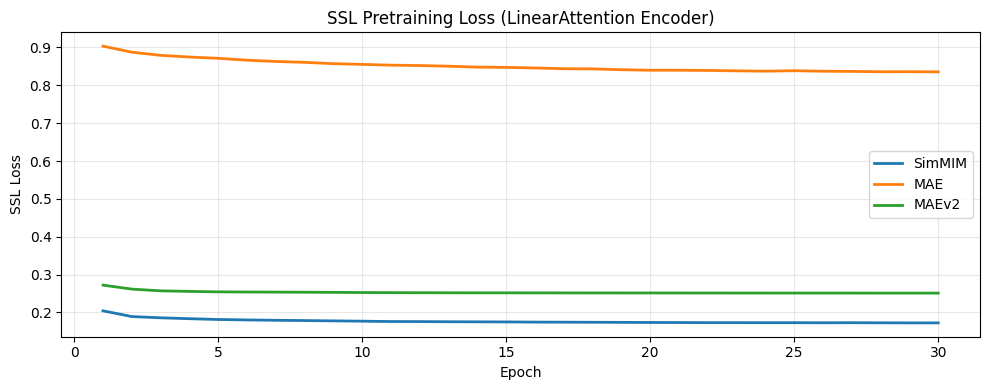

In [29]:

import gc
import time
from pathlib import Path
from contextlib import nullcontext
from tqdm import tqdm

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

try:
    from torch.amp import autocast as amp_autocast             
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import GradScaler
except Exception:
    GradScaler = None


def get_autocast_context(device: torch.device, enabled: bool):
    if not enabled or device.type != "cuda":
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            return amp_autocast(enabled=True)

    from torch.cuda.amp import autocast as cuda_autocast
    return cuda_autocast(enabled=True)


print("=" * 70)
print("Self-Supervised Pretraining (LinearAttention Encoder): SimMIM + MAE + MAEv2")
print("=" * 70)

if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

pretrain_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key="jet",
)

pretrain_dataset = TransformedDataset(pretrain_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

print(f"Pretraining samples: {len(pretrain_dataset)} | batches: {len(pretrain_loader)}")

PRETRAIN_EPOCHS = 30
print(f"Using PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} for each SSL model", flush=True)

assert PRETRAIN_EPOCHS >= 10, (
    f"PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and PRETRAIN_EPOCHS>=10."
)

SSL_PRETRAIN_CONFIGS = {
    "SimMIM": {
        "cls": SimMIMPretrainer,
        "kwargs": {"mask_ratio": 0.50},
        "ckpt": "linear_vit_pretrain_simmim_vit-5_chnges.pt",
        "plot_label": "SimMIM Loss",
    },
    "MAE": {
        "cls": MAEPretrainer,
        "kwargs": {"mask_ratio": 0.75},
        "ckpt": "linear_vit_pretrain_mae_vit-5_chnges.pt",
        "plot_label": "MAE Loss",
    },
    "MAEv2": {
        "cls": MAEv2Pretrainer,
        "kwargs": {"mask_ratio": 0.85, "block_masking": True},
        "ckpt": "linear_vit_pretrain_maev2_vit-5_chnges.pt",
        "plot_label": "MAEv2 Loss",
    },
}

CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_ENCODER_PATHS = {}
pretrained_encoder_states = {}
pretrain_losses_by_method = {}
pretrain_times = {}

for ssl_name, cfg in SSL_PRETRAIN_CONFIGS.items():
    print("\n" + "-" * 70)
    print(f"[FULL RUN] Pretraining {ssl_name} for {PRETRAIN_EPOCHS} epochs")
    print("-" * 70)

    seed_everything(SEED)
    pretrain_model = cfg["cls"](**cfg["kwargs"]).to(DEVICE)
    pretrain_params = sum(p.numel() for p in pretrain_model.parameters() if p.requires_grad)
    print(f"{ssl_name} parameters: {pretrain_params:,} ({pretrain_params/1e6:.2f}M)")

    pretrain_optimizer = torch.optim.AdamW(
        pretrain_model.parameters(),
        lr=LR_PRETRAIN,
        weight_decay=WEIGHT_DECAY,
    )
    pretrain_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        pretrain_optimizer,
        T_max=PRETRAIN_EPOCHS,
        eta_min=1e-6,
    )

    use_amp = USE_AMP and (DEVICE.type == "cuda")
    pretrain_scaler = GradScaler(enabled=use_amp) if GradScaler is not None else None

    pretrain_losses = []
    pretrain_start = time.time()

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        pretrain_model.train()
        ep_loss = 0.0

        for batch in tqdm(pretrain_loader, desc=f"  {ssl_name} [{epoch}/{PRETRAIN_EPOCHS}]", leave=False):
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))

            pretrain_optimizer.zero_grad(set_to_none=True)

            with get_autocast_context(DEVICE, enabled=use_amp):
                loss, _, _ = pretrain_model(imgs)

            if pretrain_scaler is not None:
                pretrain_scaler.scale(loss).backward()
                pretrain_scaler.unscale_(pretrain_optimizer)
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_scaler.step(pretrain_optimizer)
                pretrain_scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
                pretrain_optimizer.step()

            ep_loss += float(loss.item())

        ep_loss /= max(1, len(pretrain_loader))
        pretrain_losses.append(ep_loss)
        pretrain_scheduler.step()

        if epoch % 5 == 0 or epoch == PRETRAIN_EPOCHS:
            print(f"  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | loss={ep_loss:.4f}", flush=True)

    elapsed = time.time() - pretrain_start
    pretrain_times[ssl_name] = elapsed
    pretrain_losses_by_method[ssl_name] = pretrain_losses
    print(f"{ssl_name} pretraining complete in {elapsed:.1f}s", flush=True)

    encoder_state = pretrain_model.get_encoder_state_dict()
    save_path = (CKPT_DIR / cfg["ckpt"]).resolve()
    torch.save(encoder_state, save_path)

    PRETRAINED_ENCODER_PATHS[ssl_name] = str(save_path)
    pretrained_encoder_states[ssl_name] = encoder_state
    print(f"Saved {ssl_name} encoder -> {save_path}", flush=True)

    del pretrain_model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]
pretrained_encoder_state = pretrained_encoder_states["SimMIM"]

print("\nSaved pretrained encoder checkpoints:")
for n, p in PRETRAINED_ENCODER_PATHS.items():
    print(f"  {n}: {p}")

plt.figure(figsize=(10, 4))
for ssl_name, losses in pretrain_losses_by_method.items():
    plt.plot(range(1, len(losses) + 1), losses, linewidth=2, label=ssl_name)
plt.xlabel("Epoch")
plt.ylabel("SSL Loss")
plt.title("SSL Pretraining Loss (LinearAttention Encoder)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Section 10: Fine-tune Pretrained Linear Attention ViT Variants

> Requirement alignment: fine-tune **SimMIM-pretrained, MAE-pretrained, and MAEv2-pretrained** Linear Attention ViT models with low learning rate and compare against scratch and other baselines.

Loading pretrained encoder checkpoints:
  SimMIM: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_simmim_vit-5_chnges.pt
  MAE: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_mae_vit-5_chnges.pt
  MAEv2: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\linear_vit_pretrain_maev2_vit-5_chnges.pt

[FULL RUN] Fine-tuning Linear Attention ViT (SimMIM-pretrained)

Experiment (UW-Loss): Linear Attention ViT (SimMIM-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 70/110 block params.
Parameters: 8,235,907 (8.24M)
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.6935 | val_loss=0.9220 | val_f1=0.3483 | val_acc=0.4975 | val_mae=43.6367 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[29/35]:   0%|                                                                                 | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 29/35] end | train_loss=0.5957 | val_loss=0.4080 | val_f1=0.8695 | val_acc=0.8695 | val_mae=21.8652 | lr=4.291e-06 | finite_steps=250/250 | nonfinite_steps=0
Early stop at epoch 29 (best F1=0.8750)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (SimMIM-pretrained) -- Final Metrics
  Classification:
    Accuracy       : 0.8750
    Balanced Acc.  : 0.8751
    F1 (macro)     : 0.8750
    Precision      : 0.8750
    Recall         : 0.8751
    ROC-AUC        : 0.9390
    PR-AUC         : 0.9197
    ECE            : 0.0286
  Regression:
    MSE            : 1112.3878
    MAE            : 22.0543
    R²             : 0.6193
Inference speed: 16.52 ms/sample
Training time: 2698.0s | Peak GPU: 1074 MB

Fine-tuning complete for SimMIM.


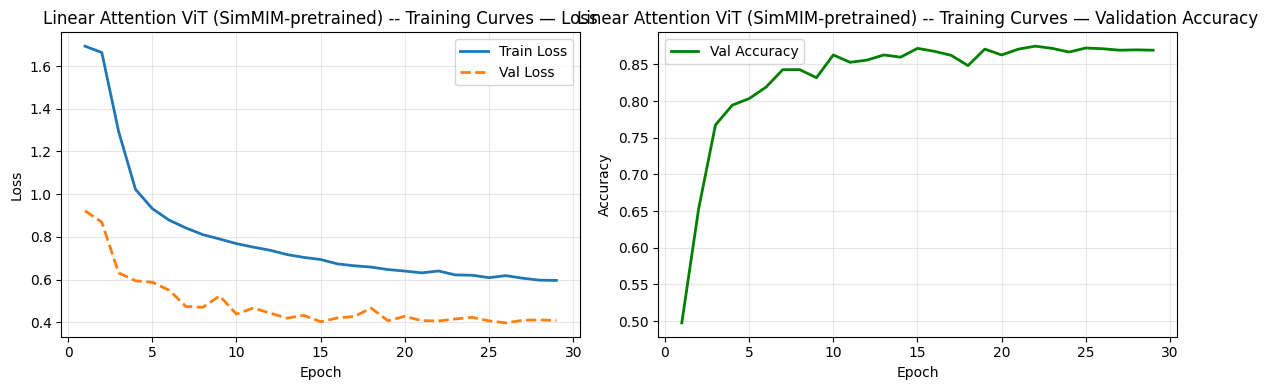

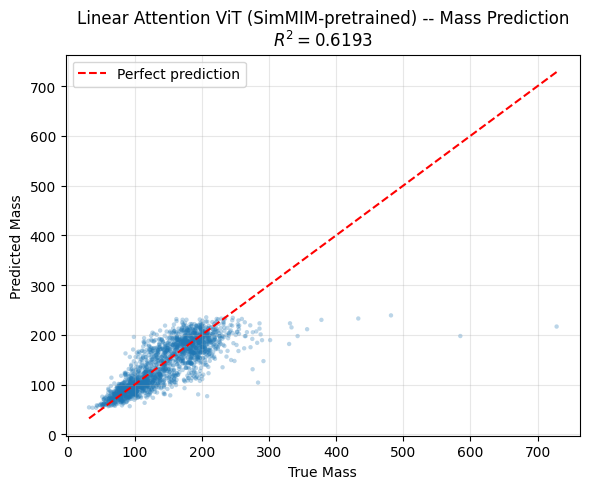

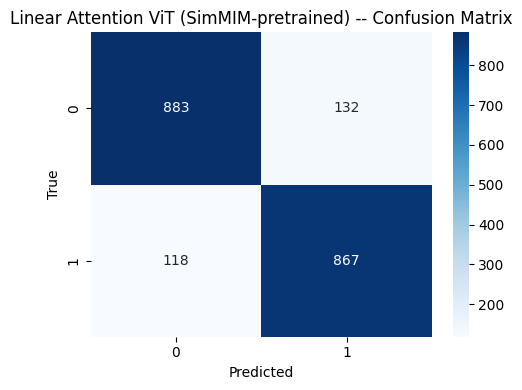


[FULL RUN] Fine-tuning Linear Attention ViT (MAE-pretrained)

Experiment (UW-Loss): Linear Attention ViT (MAE-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 70/110 block params.
Parameters: 8,235,907 (8.24M)
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.6961 | val_loss=0.9214 | val_f1=0.3587 | val_acc=0.5155 | val_mae=43.7540 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[35/35]:   0%|                                                                                 | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 35/35] end | train_loss=0.5684 | val_loss=0.4005 | val_f1=0.8718 | val_acc=0.8720 | val_mae=22.3775 | lr=1.070e-06 | finite_steps=250/250 | nonfinite_steps=0


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAE-pretrained) -- Final Metrics
  Classification:
    Accuracy       : 0.8720
    Balanced Acc.  : 0.8728
    F1 (macro)     : 0.8718
    Precision      : 0.8763
    Recall         : 0.8728
    ROC-AUC        : 0.9392
    PR-AUC         : 0.9246
    ECE            : 0.0325
  Regression:
    MSE            : 1122.2405
    MAE            : 22.3775
    R²             : 0.6160
Inference speed: 16.80 ms/sample
Training time: 2175.5s | Peak GPU: 1107 MB

Fine-tuning complete for MAE.


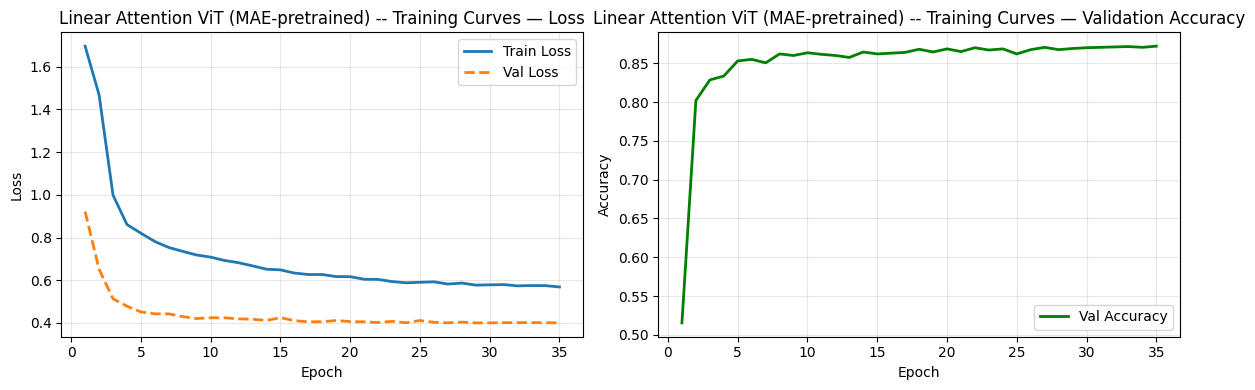

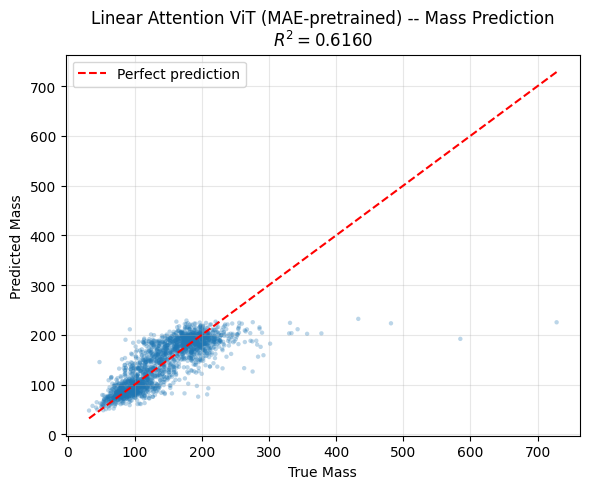

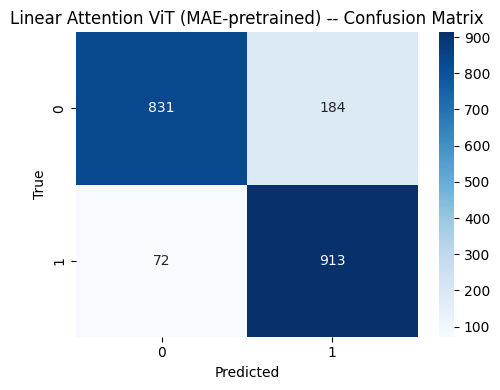


[FULL RUN] Fine-tuning Linear Attention ViT (MAEv2-pretrained)

Experiment (UW-Loss): Linear Attention ViT (MAEv2-pretrained)
lr=3.000e-05, wd=0.0001, epochs=35
Loading pretrained encoder weights...
Loaded 70/110 block params.
Parameters: 8,235,907 (8.24M)
[Epoch 1/35] start | lr=0.000e+00


[1/35]:   0%|                                                                                  | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 1/35] end | train_loss=1.6942 | val_loss=0.9202 | val_f1=0.4035 | val_acc=0.5200 | val_mae=43.6940 | lr=0.000e+00 | finite_steps=250/250 | nonfinite_steps=0
[Epoch 2/35] start | lr=1.000e-05


[2/35]:   0%|                                                                                  | 0/250 [00:00<…

...

[27/35]:   0%|                                                                                 | 0/250 [00:00<…

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

[Epoch 27/35] end | train_loss=0.7382 | val_loss=0.4511 | val_f1=0.8453 | val_acc=0.8455 | val_mae=23.6122 | lr=6.301e-06 | finite_steps=250/250 | nonfinite_steps=0
Early stop at epoch 27 (best F1=0.8473)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (MAEv2-pretrained) -- Final Metrics
  Classification:
    Accuracy       : 0.8475
    Balanced Acc.  : 0.8482
    F1 (macro)     : 0.8473
    Precision      : 0.8502
    Recall         : 0.8482
    ROC-AUC        : 0.9151
    PR-AUC         : 0.8935
    ECE            : 0.0232
  Regression:
    MSE            : 1240.1278
    MAE            : 23.8041
    R²             : 0.5756
Inference speed: 15.83 ms/sample
Training time: 1678.7s | Peak GPU: 1140 MB

Fine-tuning complete for MAEv2.


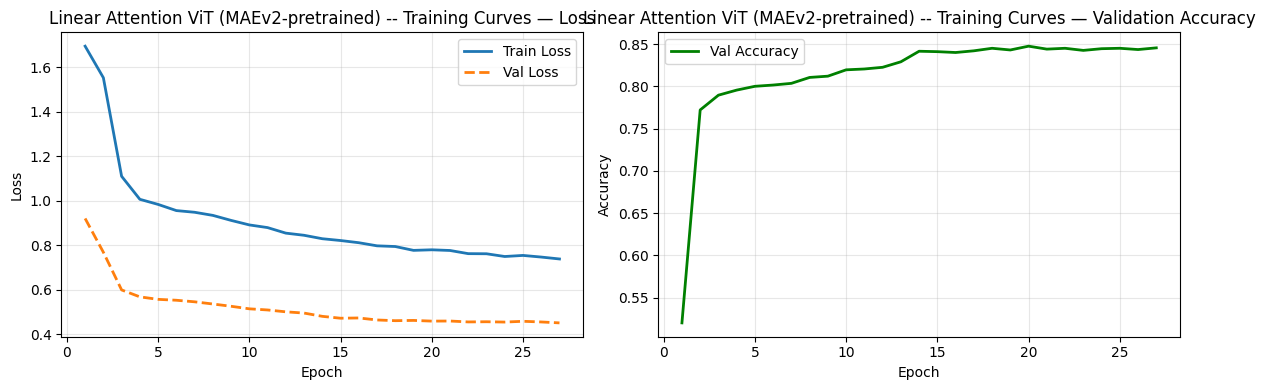

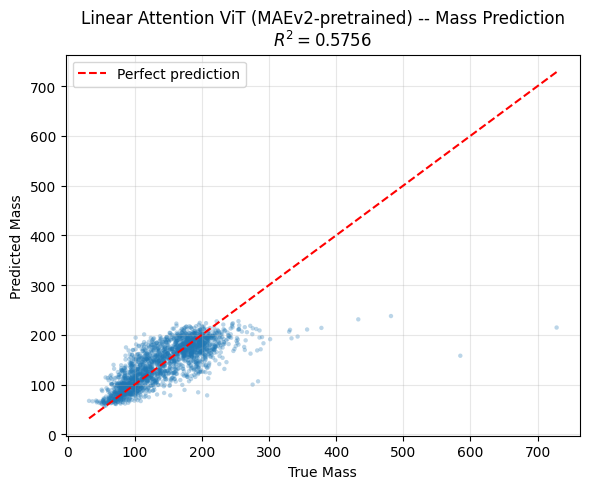

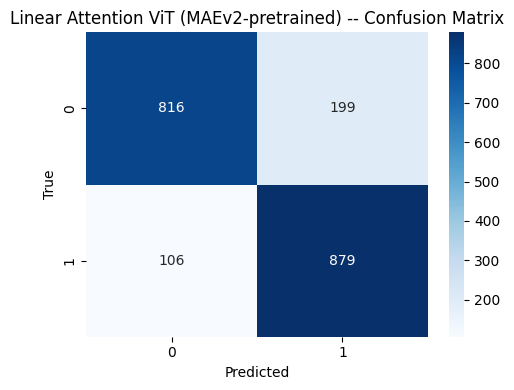

In [34]:

from pathlib import Path
from contextlib import nullcontext
import copy
import gc
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

PRINT_EPOCH_START = True
PRINT_EPOCH_END = True
EPOCH_STATUS_EVERY = 1                                        
SHOW_TQDM_BAR = True                                            
LOG_EVERY_N_BATCHES = 0                           

def log(msg):
    print(msg, flush=True)

try:
    from torch.amp import autocast as amp_autocast
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import autocast as cuda_autocast
except Exception:
    cuda_autocast = None


def get_autocast_context(device, enabled=True):
    if (not enabled) or (device.type != "cuda"):
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            try:
                return amp_autocast(enabled=True)
            except Exception:
                pass

    if cuda_autocast is not None:
        return cuda_autocast(enabled=True)

    return nullcontext()


def autocast(*args, **kwargs):
    enabled = bool(kwargs.get("enabled", True))
    return get_autocast_context(DEVICE, enabled=enabled)


def run_experiment_uw_quiet(
    model_class,
    model_name,
    train_loader,
    val_loader,
    pretrained_state=None,
    epochs=None,
    lr=None,
    weight_decay=None,
    patience=None,
    seed=None,
):
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    log(f"\n{'='*60}")
    log(f"Experiment (UW-Loss): {model_name}")
    log(f"lr={lr:.3e}, wd={weight_decay}, epochs={epochs}")
    log(f"{'='*60}")

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        log("Loading pretrained encoder weights...")
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])

            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]

            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v

            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            log(f"Loaded {len(matched)}/{len(model_blocks_sd)} block params.")
        except Exception as e:
            log(f"Warning: partial weight loading ({e}). Continuing.")

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    log(f"Parameters: {params:,} ({params/1e6:.2f}M)")

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(
        optimizer,
        warmup_epochs=warmup_epochs,
        total_epochs=epochs,
        eta_min=1e-6,
    )

    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mse": [],
        "val_acc": [],
        "val_f1": [],
        "val_bal_acc": [],
        "lr": [],
    }

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train()
        uw_loss.train()

        current_lr = optimizer.param_groups[0]["lr"]
        total_loss = total_mse = total_ce = 0.0
        finite_steps = 0
        nonfinite_steps = 0
        first_nonfinite_reason = None

        if PRINT_EPOCH_START and (epoch % EPOCH_STATUS_EVERY == 0 or epoch == 1 or epoch == epochs):
            log(f"[Epoch {epoch}/{epochs}] start | lr={current_lr:.3e}")

        iterator = tqdm(
            train_loader,
            desc=f"[{epoch}/{epochs}]",
            leave=True,
            dynamic_ncols=True,
            disable=(not SHOW_TQDM_BAR),
        )

        for imgs, masses, labels in iterator:
            imgs = imgs.to(DEVICE)
            masses = masses.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)

                if not torch.isfinite(mass_pred).all():
                    nonfinite_steps += 1
                    if first_nonfinite_reason is None:
                        first_nonfinite_reason = "mass_pred non-finite"
                    continue

                if not torch.isfinite(class_logits).all():
                    nonfinite_steps += 1
                    if first_nonfinite_reason is None:
                        first_nonfinite_reason = "class_logits non-finite"
                    continue

                masses_norm = masses                                           

                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)

                ce = F.cross_entropy(class_logits, labels)

                if (not torch.isfinite(mse)) or (not torch.isfinite(ce)):
                    nonfinite_steps += 1
                    if first_nonfinite_reason is None:
                        first_nonfinite_reason = "mse/ce non-finite"
                    continue

                loss = uw_loss(ce, mse)

            if not torch.isfinite(loss):
                nonfinite_steps += 1
                if first_nonfinite_reason is None:
                    first_nonfinite_reason = "uw loss non-finite"
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()

            total_loss += float(loss.item())
            total_mse += float(mse.item())
            total_ce += float(ce.item())
            finite_steps += 1

        if finite_steps == 0:
            log(
                f"[Epoch {epoch}/{epochs}] end | all steps non-finite; stopping "
                f"(nonfinite_steps={nonfinite_steps}, reason={first_nonfinite_reason})"
            )
            break

        train_stats = {
            "loss": total_loss / finite_steps,
            "mse": total_mse / finite_steps,
            "ce": total_ce / finite_steps,
        }

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)

        val_results["mass_pred"] = np.nan_to_num(val_results["mass_pred"], nan=0.0, posinf=1e6, neginf=-1e6)
        val_results["mass_true"] = np.nan_to_num(val_results["mass_true"], nan=0.0, posinf=1e6, neginf=-1e6)
        val_results["class_probs"] = np.nan_to_num(val_results["class_probs"], nan=0.0, posinf=1.0, neginf=0.0)

        row_sum = val_results["class_probs"].sum(axis=1, keepdims=True)
        row_sum = np.where(row_sum <= 0, 1.0, row_sum)
        val_results["class_probs"] = val_results["class_probs"] / row_sum

        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]

        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            best_state = ema.state_dict() if ema is not None else copy.deepcopy(model.state_dict())

        if PRINT_EPOCH_END and (epoch % EPOCH_STATUS_EVERY == 0 or epoch == epochs):
            log(
                f"[Epoch {epoch}/{epochs}] end | "
                f"train_loss={train_stats['loss']:.4f} | "
                f"val_loss={val_results['loss']:.4f} | "
                f"val_f1={val_f1:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
                f"val_mae={val_mae:.4f} | lr={current_lr:.3e} | "
                f"finite_steps={finite_steps}/{len(train_loader)} | nonfinite_steps={nonfinite_steps}"
            )

        if early_stopper(val_f1):
            log(f"Early stop at epoch {epoch} (best F1={best_f1:.4f})")
            break

    train_time = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6 if DEVICE.type == "cuda" else 0.0

    if best_state is not None:
        model.load_state_dict(best_state)

    final_results = evaluate_model(model, val_loader)
    final_results["mass_pred"] = np.nan_to_num(final_results["mass_pred"], nan=0.0, posinf=1e6, neginf=-1e6)
    final_results["mass_true"] = np.nan_to_num(final_results["mass_true"], nan=0.0, posinf=1e6, neginf=-1e6)
    final_results["class_probs"] = np.nan_to_num(final_results["class_probs"], nan=0.0, posinf=1.0, neginf=0.0)

    rs = final_results["class_probs"].sum(axis=1, keepdims=True)
    rs = np.where(rs <= 0, 1.0, rs)
    final_results["class_probs"] = final_results["class_probs"] / rs

    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    log(f"Inference speed: {inference_ms:.2f} ms/sample")
    log(f"Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB")

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


if "PRETRAINED_ENCODER_PATHS" not in globals() or not PRETRAINED_ENCODER_PATHS:
    raise RuntimeError("PRETRAINED_ENCODER_PATHS not found. Run Section 9 first.")

log("Loading pretrained encoder checkpoints:")
for name, path in PRETRAINED_ENCODER_PATHS.items():
    log(f"  {name}: {path}")
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}")

assert EPOCHS >= 10, f"EPOCHS={EPOCHS} too low; set RUN_MODE='full' and EPOCHS>=10."

FINETUNE_LR = LR * 0.1
result_linear_pretrained_all = {}

for ssl_name, ckpt_path in PRETRAINED_ENCODER_PATHS.items():
    log("\n" + "=" * 70)
    log(f"[FULL RUN] Fine-tuning Linear Attention ViT ({ssl_name}-pretrained)")
    log("=" * 70)

    try:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except TypeError:
        pretrained_encoder_state = torch.load(ckpt_path, map_location="cpu")

    result_linear_pretrained_all[ssl_name] = run_experiment_uw_quiet(
        model_class=LinearAttentionViT,
        model_name=f"Linear Attention ViT ({ssl_name}-pretrained)",
        train_loader=train_loader,
        val_loader=val_loader,
        pretrained_state=pretrained_encoder_state,
        epochs=EPOCHS,
        lr=FINETUNE_LR,
        weight_decay=WEIGHT_DECAY,
    )

    log(f"\nFine-tuning complete for {ssl_name}.")
    plot_training_curves(
        result_linear_pretrained_all[ssl_name]["history"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Training Curves",
    )
    plot_mass_scatter(
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_true"],
        result_linear_pretrained_all[ssl_name]["final_results"]["mass_pred"],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Mass Prediction",
    )
    plot_confusion_matrix(
        result_linear_pretrained_all[ssl_name]["final_metrics"]["confusion_matrix"],
        class_names=[str(i) for i in range(NUM_CLASSES)],
        title=f"Linear Attention ViT ({ssl_name}-pretrained) -- Confusion Matrix",
    )

result_linear_pretrained = result_linear_pretrained_all["SimMIM"]
PRETRAINED_ENCODER_PATH = PRETRAINED_ENCODER_PATHS["SimMIM"]

## Section 11: Train Linear Attention ViT from Scratch

> Requirement alignment: scratch baseline for direct comparison against pretrained linear attention model.

[FULL RUN] Training Linear Attention ViT (scratch) for 35 epochs

  Experiment (UW-Loss): Linear Attention ViT (scratch)_vit-5_chnges
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,235,907 (8.24M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.6939 | val_loss=0.9227 | val_f1=0.4326 | val_acc=0.4840 | val_mae=43.6227
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [19/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 19/35] end   | train_loss=0.1290 | val_loss=0.5486 | val_f1=0.8366 | val_acc=0.8370 | val_mae=23.9525
  Early stop at epoch 19 (best F1=0.8419)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Linear Attention ViT (scratch)_vit-5_chnges -- Final Metrics
  Classification:
    Accuracy       : 0.8420
    Balanced Acc.  : 0.8419
    F1 (macro)     : 0.8419
    Precision      : 0.8420
    Recall         : 0.8419
    ROC-AUC        : 0.9155
    PR-AUC         : 0.8861
    ECE            : 0.0224
  Regression:
    MSE            : 1216.4567
    MAE            : 23.5884
    R²             : 0.5837
  Inference speed: 15.82 ms/sample
  Training time: 1142.6s | Peak GPU: 1140 MB

Linear Attention ViT (scratch) training complete.


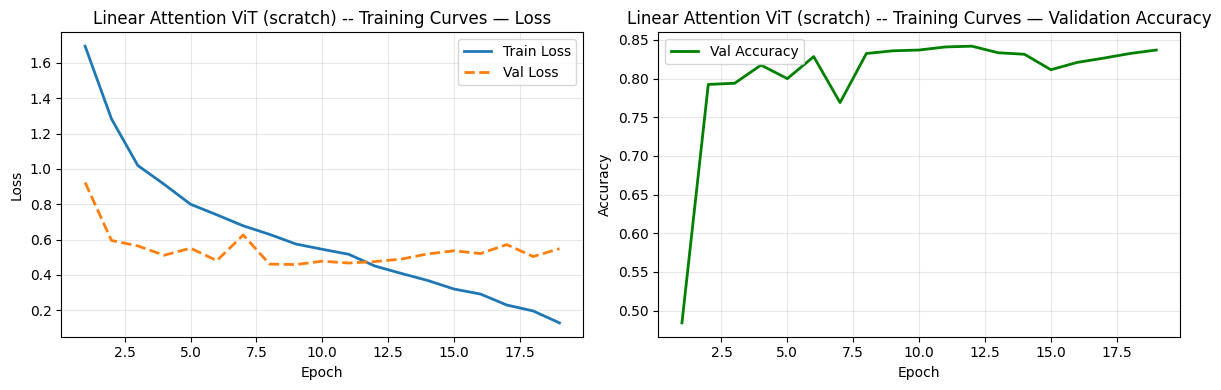

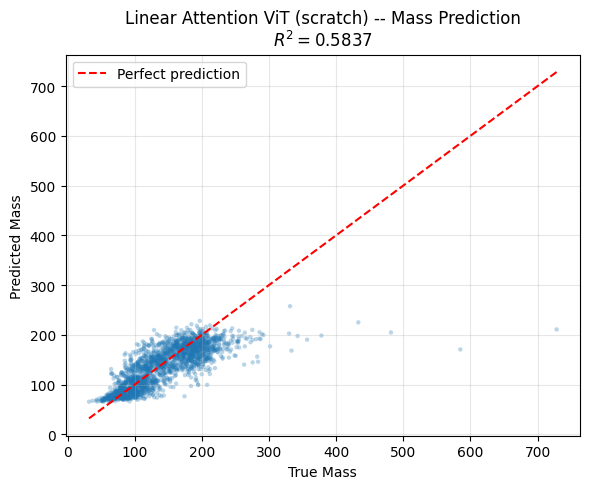

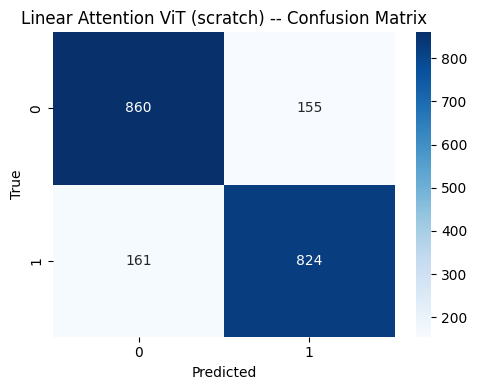

In [35]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Linear Attention ViT (scratch) for {EPOCHS} epochs", flush=True)

result_linear_scratch = run_experiment_uw(
    model_class=LinearAttentionViT,
    model_name="Linear Attention ViT (scratch)_vit-5_chnges",
    train_loader=train_loader,
    val_loader=val_loader,
    pretrained_state=None,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nLinear Attention ViT (scratch) training complete.")
plot_training_curves(result_linear_scratch["history"], title="Linear Attention ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_linear_scratch["final_results"]["mass_true"],
    result_linear_scratch["final_results"]["mass_pred"],
    title="Linear Attention ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_linear_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Linear Attention ViT (scratch) -- Confusion Matrix",
)

## Section 12 (Optional Baseline): Train Standard ViT

[FULL RUN] Training Standard ViT for 35 epochs

  Experiment (UW-Loss): Standard ViT
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,235,907 (8.24M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.6943 | val_loss=0.9230 | val_f1=0.3772 | val_acc=0.4850 | val_mae=43.6209
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [17/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 17/35] end   | train_loss=0.3536 | val_loss=0.5840 | val_f1=0.8229 | val_acc=0.8255 | val_mae=25.2006
  Early stop at epoch 17 (best F1=0.8522)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  Standard ViT -- Final Metrics
  Classification:
    Accuracy       : 0.8530
    Balanced Acc.  : 0.8543
    F1 (macro)     : 0.8522
    Precision      : 0.8636
    Recall         : 0.8543
    ROC-AUC        : 0.9178
    PR-AUC         : 0.8913
    ECE            : 0.0159
  Regression:
    MSE            : 1268.8384
    MAE            : 23.9529
    R²             : 0.5658
  Inference speed: 15.60 ms/sample
  Training time: 1027.3s | Peak GPU: 1200 MB

Standard ViT training complete.


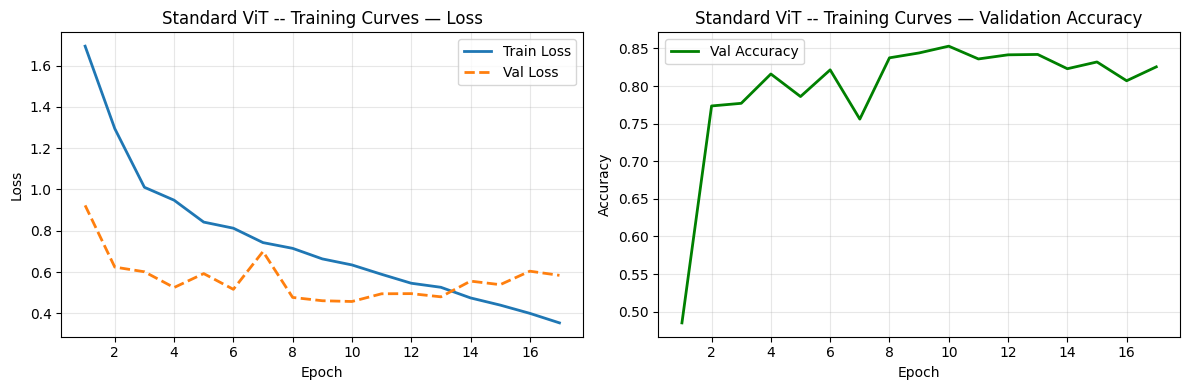

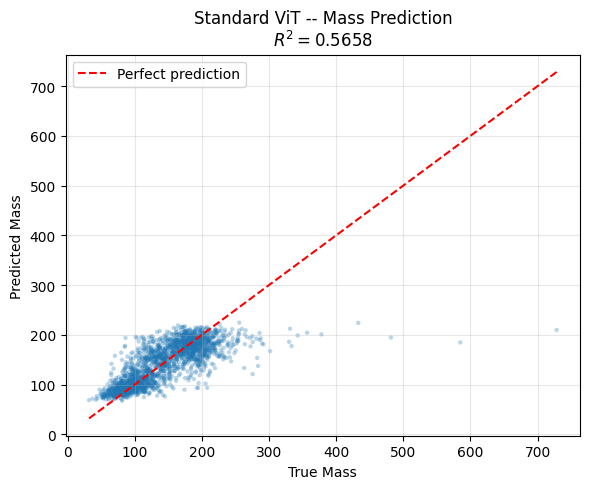

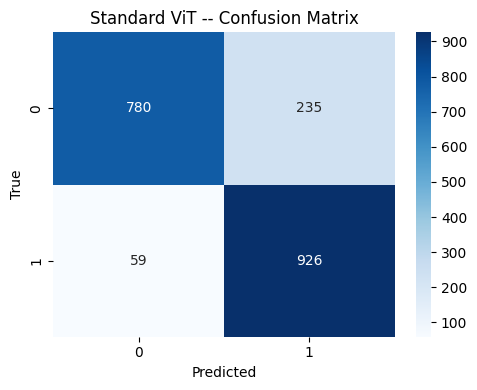

In [36]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Standard ViT for {EPOCHS} epochs", flush=True)

result_vit = run_experiment_uw(
    model_class=StandardViT,
    model_name="Standard ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nStandard ViT training complete.")
plot_training_curves(result_vit["history"], title="Standard ViT -- Training Curves")
plot_mass_scatter(
    result_vit["final_results"]["mass_true"],
    result_vit["final_results"]["mass_pred"],
    title="Standard ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Standard ViT -- Confusion Matrix",
)


## Section 13 (Optional Baseline): Train XCiT ViT from Scratch

[FULL RUN] Training XCiT ViT (scratch baseline) for 35 epochs

  Experiment (UW-Loss): XCiT ViT (scratch)
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,305,107 (8.31M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.6929 | val_loss=0.9213 | val_f1=0.3300 | val_acc=0.4925 | val_mae=43.6402
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [9/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 9/35] end   | train_loss=1.0025 | val_loss=0.7999 | val_f1=0.3367 | val_acc=0.5075 | val_mae=25.1762
  Early stop at epoch 9 (best F1=0.3367)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  XCiT ViT (scratch) -- Final Metrics
  Classification:
    Accuracy       : 0.5075
    Balanced Acc.  : 0.5000
    F1 (macro)     : 0.3367
    Precision      : 0.2537
    Recall         : 0.5000
    ROC-AUC        : 0.5000
    PR-AUC         : 0.4925
    ECE            : 0.0038
  Regression:
    MSE            : 1369.3727
    MAE            : 25.1762
    R²             : 0.5314
  Inference speed: 23.53 ms/sample
  Training time: 598.0s | Peak GPU: 1389 MB

XCiT ViT (scratch) training complete.


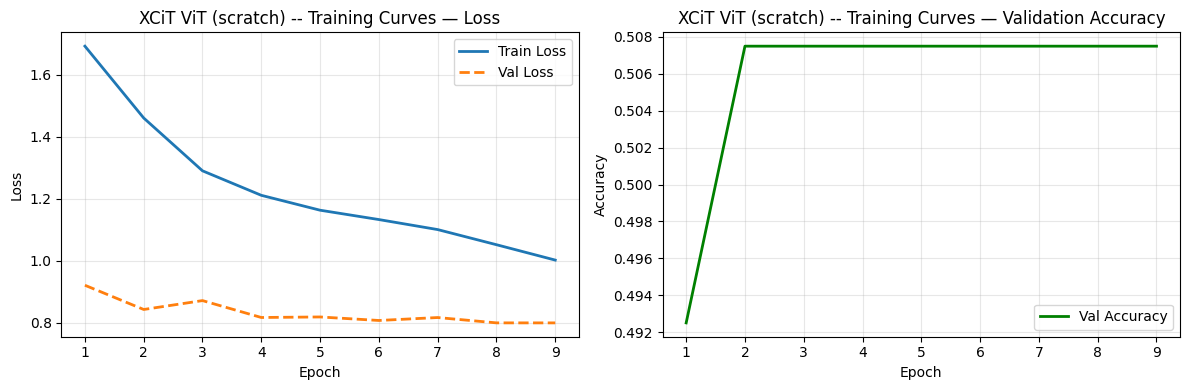

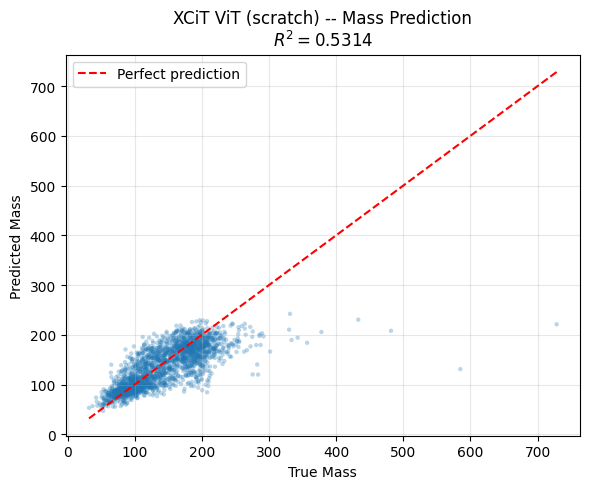

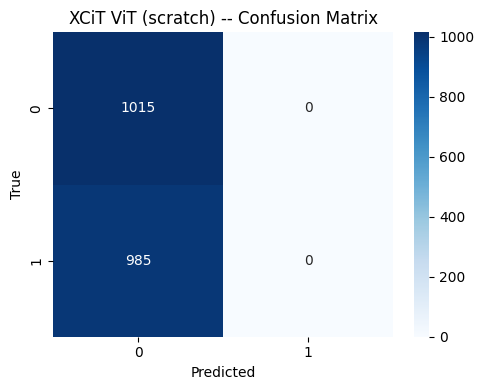

In [37]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training XCiT ViT (scratch baseline) for {EPOCHS} epochs", flush=True)

result_xcit_scratch = run_experiment_uw(
    model_class=XCiTViT,
    model_name="XCiT ViT (scratch)",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nXCiT ViT (scratch) training complete.")
plot_training_curves(result_xcit_scratch["history"], title="XCiT ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_xcit_scratch["final_results"]["mass_true"],
    result_xcit_scratch["final_results"]["mass_pred"],
    title="XCiT ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_xcit_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="XCiT ViT (scratch) -- Confusion Matrix",
)

## Section 14: Train L2ViT

[FULL RUN] Training L2ViT for 35 epochs

  Experiment (UW-Loss): L2ViT
  lr=0.0003, wd=0.0001, epochs=35
  Parameters: 8,394,632 (8.39M)
  [Epoch 1/35] start | lr=0.00e+00


  [1/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 1/35] end   | train_loss=1.6932 | val_loss=0.9213 | val_f1=0.3367 | val_acc=0.5075 | val_mae=43.6447
  [Epoch 2/35] start | lr=1.00e-04


  [2/35]:   0%|          | 0/250 [00:00<?, ?it/s]

...

  [8/35]:   0%|          | 0/250 [00:00<?, ?it/s]

  eval :   0%|          | 0/63 [00:00<?, ?it/s]

  [Epoch 8/35] end   | train_loss=0.7527 | val_loss=0.7719 | val_f1=0.3367 | val_acc=0.5075 | val_mae=22.2074
  Early stop at epoch 8 (best F1=0.3367)


  eval :   0%|          | 0/63 [00:00<?, ?it/s]


  L2ViT -- Final Metrics
  Classification:
    Accuracy       : 0.5075
    Balanced Acc.  : 0.5000
    F1 (macro)     : 0.3367
    Precision      : 0.2537
    Recall         : 0.5000
    ROC-AUC        : 0.5000
    PR-AUC         : 0.4925
    ECE            : 0.0072
  Regression:
    MSE            : 995.4363
    MAE            : 21.1166
    R²             : 0.6594
  Inference speed: 25.14 ms/sample
  Training time: 513.4s | Peak GPU: 1288 MB

L2ViT training complete.


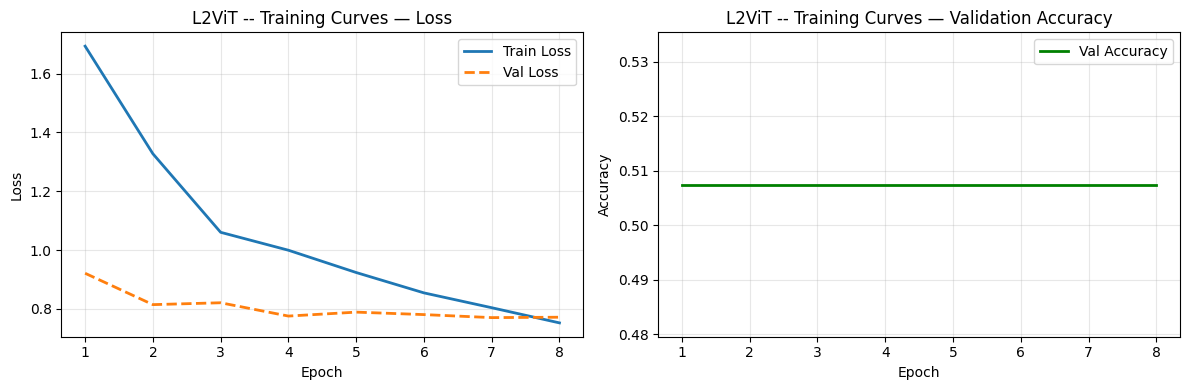

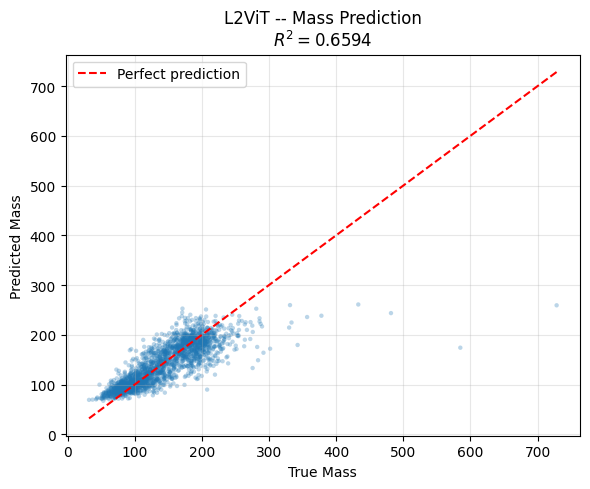

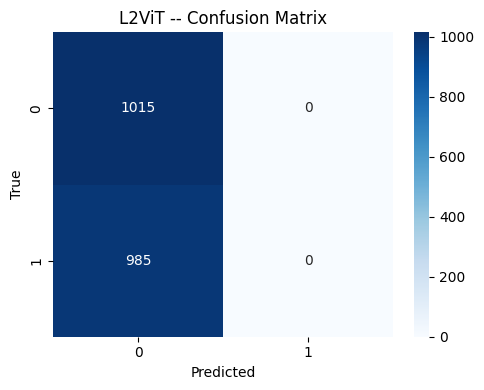

In [38]:

assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training L2ViT for {EPOCHS} epochs", flush=True)

result_l2vit = run_experiment_uw(
    model_class=L2ViT,
    model_name="L2ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nL2ViT training complete.")
plot_training_curves(result_l2vit["history"], title="L2ViT -- Training Curves")
plot_mass_scatter(
    result_l2vit["final_results"]["mass_true"],
    result_l2vit["final_results"]["mass_pred"],
    title="L2ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_l2vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="L2ViT -- Confusion Matrix",
)

## Section 15: Benchmark Comparison & Model Saving

Comprehensive comparison across all trained model variants plus model weight saving.


BENCHMARK COMPARISON
                                         Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                                        
Linear Attention ViT (SimMIM-pretrained)   0.8750    0.8751  0.8750  0.9390  0.9197  0.0286  1112.3878  22.0543  0.6193         2698.0          16.52         1074  8,235,907
Linear Attention ViT (MAE-pretrained)      0.8720    0.8728  0.8718  0.9392  0.9246  0.0325  1122.2405  22.3775  0.6160         2175.5          16.80         1107  8,235,907
Linear Attention ViT (MAEv2-pretrained)    0.8475    0.8482  0.8473  0.9151  0.8935  0.0232  1240.1278  23.8041  0.5756         1678.7          15.83         1140  8,235,907
Linear Attention ViT (scratch)             0.8420    0.8419  0.8419  0.9155  0.8861  0.0224  1216.4567  23.5

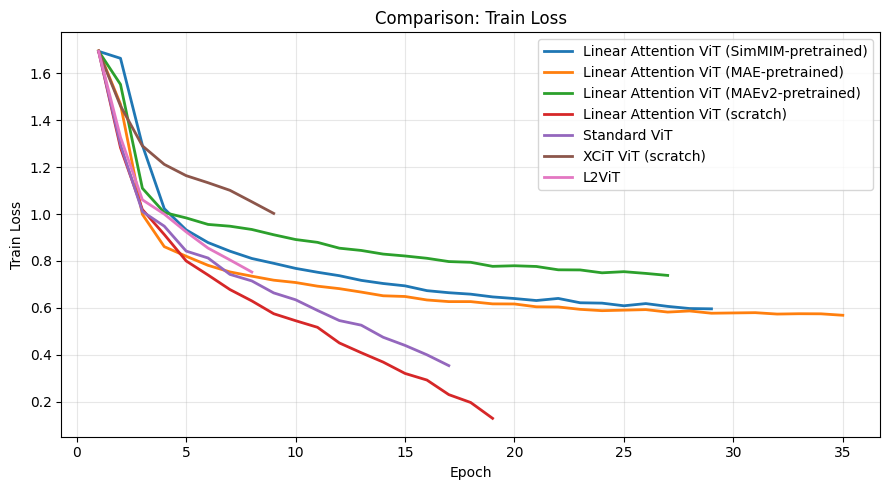

--- Comparison: Validation Accuracy ---


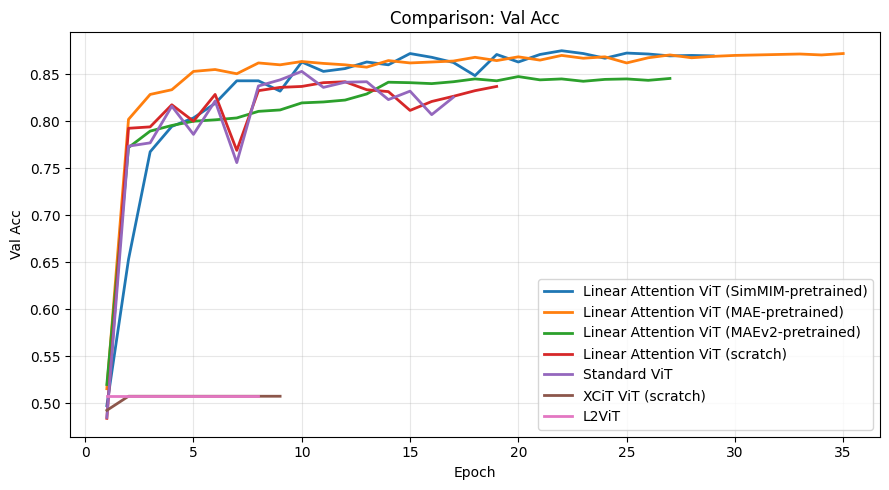

--- Mass Prediction Scatter Plots ---


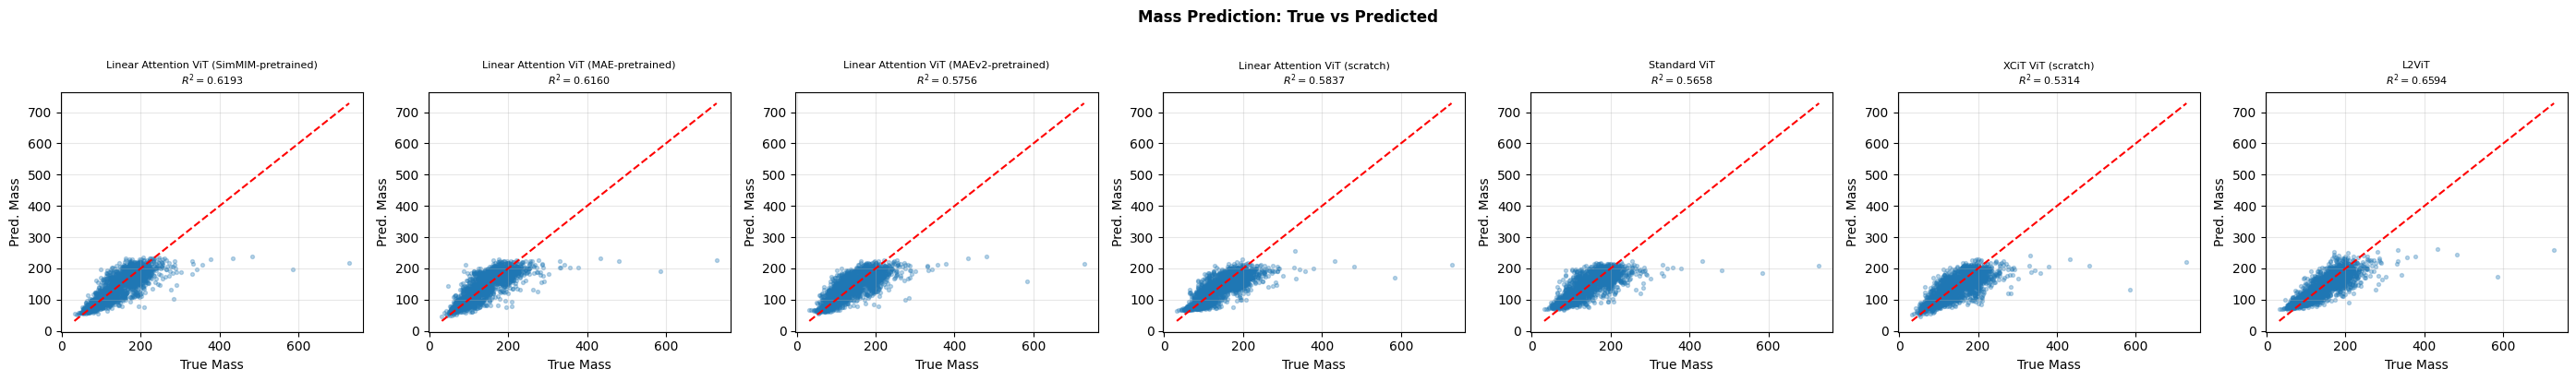

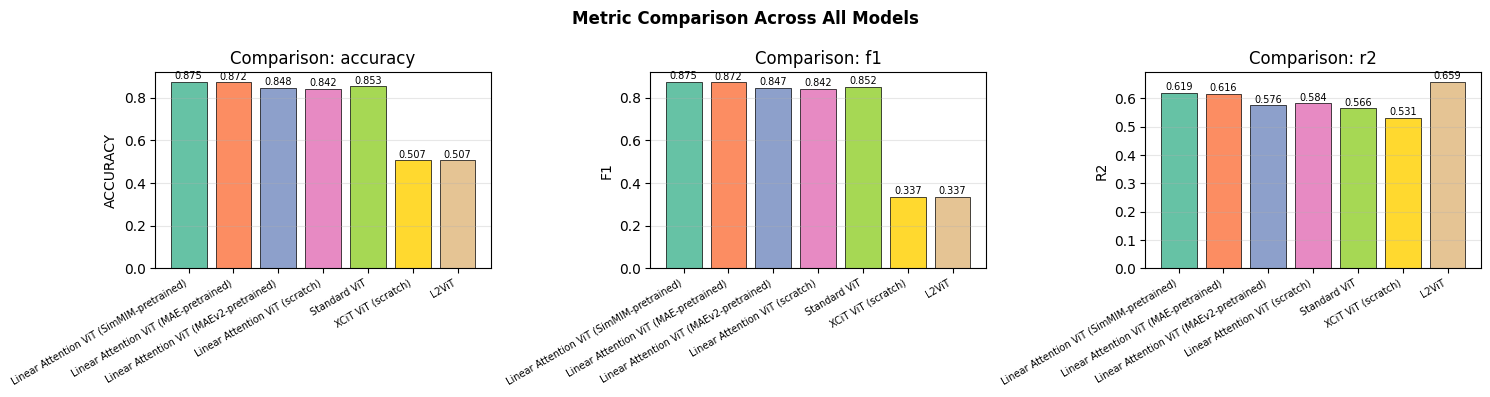

In [39]:

import os

all_results = {
    "Linear Attention ViT (SimMIM-pretrained)": result_linear_pretrained_all["SimMIM"],
    "Linear Attention ViT (MAE-pretrained)": result_linear_pretrained_all["MAE"],
    "Linear Attention ViT (MAEv2-pretrained)": result_linear_pretrained_all["MAEv2"],
    "Linear Attention ViT (scratch)": result_linear_scratch,
    "Standard ViT": result_vit,
    "XCiT ViT (scratch)": result_xcit_scratch,
    "L2ViT": result_l2vit,
}

rows = []
for name, res in all_results.items():
    m = res["final_metrics"]
    rows.append({
        "Model": name,
        "Accuracy": f"{m['accuracy']:.4f}",
        "Bal. Acc.": f"{m.get('balanced_accuracy', 0):.4f}",
        "F1": f"{m['f1']:.4f}",
        "ROC-AUC": f"{m.get('roc_auc', 0):.4f}",
        "PR-AUC": f"{m.get('pr_auc', 0):.4f}",
        "ECE": f"{m.get('ece', 0):.4f}",
        "MSE": f"{m['mse']:.4f}",
        "MAE": f"{m['mae']:.4f}",
        "R2": f"{m['r2']:.4f}",
        "Train Time (s)": f"{res['train_time']:.1f}",
        "Inference (ms)": f"{res['inference_ms']:.2f}",
        "GPU Mem (MB)": f"{res.get('peak_gpu_mem_mb', 0):.0f}",
        "Parameters": f"{res['params']:,}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 140, flush=True)
print("BENCHMARK COMPARISON", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
df.to_csv(results_dir / "final_benchmark_results.csv")
print(f"Results saved to {results_dir / 'final_benchmark_results.csv'}", flush=True)


models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_save_map = {
    "Linear Attention ViT (SimMIM-pretrained)": "linear_vit_simmim_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (MAE-pretrained)": "linear_vit_mae_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (MAEv2-pretrained)": "linear_vit_maev2_pretrained_vit-5_chnges.pt",
    "Linear Attention ViT (scratch)": "linear_vit_scratch_vit-5_chnges.pt",
    "Standard ViT": "vit_vit-5_chnges.pt",
    "XCiT ViT (scratch)": "xcit_scratch_vit-5_chnges.pt",
    "L2ViT": "l2vit_vit-5_chnges.pt",
}

for name, filename in model_save_map.items():
    if name in all_results and "model_state" in all_results[name]:
        save_path = models_dir / filename
        torch.save(all_results[name]["model_state"], save_path)
        print(f"Saved {name} -> {save_path}", flush=True)

if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    import shutil
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            encoder_path = models_dir / f"pretrained_encoder_{ssl_name.lower()}.pt"
            shutil.copy2(src_path, encoder_path)
            print(f"Saved pretrained encoder ({ssl_name}) -> {encoder_path}", flush=True)

print(f"\nAll model weights saved to {models_dir}/", flush=True)

print("\n--- Comparison: Training Loss ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="train_loss",
)
print("--- Comparison: Validation Accuracy ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="val_acc",
)

print("--- Mass Prediction Scatter Plots ---", flush=True)
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, all_results.items()):
    fr = res["final_results"]
    r2 = res["final_metrics"]["r2"]
    ax.scatter(fr["mass_true"], fr["mass_pred"], alpha=0.3, s=8)
    lims = [
        min(fr["mass_true"].min(), fr["mass_pred"].min()),
        max(fr["mass_true"].max(), fr["mass_pred"].max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Pred. Mass")
    ax.set_title(f"{name}\n$R^2={r2:.4f}$", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Mass Prediction: True vs Predicted", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

metric_keys = ["accuracy", "f1", "r2"]
fig, axes = plt.subplots(1, len(metric_keys), figsize=(5 * len(metric_keys), 4))
model_names = list(all_results.keys())
for ax, mk in zip(axes, metric_keys):
    vals = [all_results[n]["final_metrics"][mk] for n in model_names]
    colors = plt.cm.Set2(range(len(model_names)))
    bars = ax.bar(range(len(model_names)), vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel(mk.upper())
    ax.set_title(f"Comparison: {mk}")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
plt.suptitle("Metric Comparison Across All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
from pathlib import Path
import os
import shutil

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

if "PRETRAINED_ENCODER_PATHS" in globals() and PRETRAINED_ENCODER_PATHS:
    aligned_names = {
        "SimMIM": "linear_vit_pretrain_simmim_vit-5_chnges.pt",
        "MAE": "linear_vit_pretrain_mae_vit-5_chnges.pt",
        "MAEv2": "linear_vit_pretrain_maev2_vit-5_chnges.pt",
    }
    for ssl_name, src_path in PRETRAINED_ENCODER_PATHS.items():
        if os.path.exists(src_path):
            aligned_encoder_path = models_dir / aligned_names.get(ssl_name, f"linear_vit_pretrain_{ssl_name.lower()}.pt")
            shutil.copy2(src_path, aligned_encoder_path)
            print(f"Saved requirement-aligned pretrained encoder ({ssl_name}) -> {aligned_encoder_path}", flush=True)

if "PRETRAINED_ENCODER_PATH" in globals() and os.path.exists(PRETRAINED_ENCODER_PATH):
    legacy_path = models_dir / "linear_vit_pretrain.pt"
    shutil.copy2(PRETRAINED_ENCODER_PATH, legacy_path)
    print(f"Saved legacy pretrained encoder alias -> {legacy_path}", flush=True)

Saved requirement-aligned pretrained encoder (SimMIM) -> ..\models\linear_vit_pretrain_simmim_vit-5_chnges.pt
Saved requirement-aligned pretrained encoder (MAE) -> ..\models\linear_vit_pretrain_mae_vit-5_chnges.pt
Saved requirement-aligned pretrained encoder (MAEv2) -> ..\models\linear_vit_pretrain_maev2_vit-5_chnges.pt
Saved legacy pretrained encoder alias -> ..\models\linear_vit_pretrain.pt


## Section 16: Final Results & Analysis

In [43]:

print("\n" + "=" * 140, flush=True)
print("FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

best_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"]["accuracy"])
best_r2 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["r2"])
best_f1 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["f1"])
fastest = min(all_results, key=lambda n: all_results[n]["train_time"])
smallest = min(all_results, key=lambda n: all_results[n]["params"])
best_mse = min(all_results, key=lambda n: all_results[n]["final_metrics"]["mse"])
best_bal_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"].get("balanced_accuracy", 0))

print(f"\n  Best Classification Accuracy : {best_acc}", flush=True)
print(f"  Best Balanced Accuracy       : {best_bal_acc}", flush=True)
print(f"  Best F1 Score                : {best_f1}", flush=True)
print(f"  Best Regression R2           : {best_r2}", flush=True)
print(f"  Lowest MSE                   : {best_mse}", flush=True)
print(f"  Fastest Training             : {fastest}", flush=True)
print(f"  Smallest Model               : {smallest}", flush=True)

ssl_variants = ["SimMIM", "MAE", "MAEv2"]
scratch_acc = result_linear_scratch["final_metrics"]["accuracy"]
scratch_r2 = result_linear_scratch["final_metrics"]["r2"]

print("\n  Pretraining benefit vs scratch (Linear ViT):", flush=True)
for ssl_name in ssl_variants:
    k = f"Linear Attention ViT ({ssl_name}-pretrained)"
    pt_acc = all_results[k]["final_metrics"]["accuracy"]
    pt_r2 = all_results[k]["final_metrics"]["r2"]
    print(f"    {ssl_name:6s} | ΔAcc={pt_acc - scratch_acc:+.4f} | ΔR2={pt_r2 - scratch_r2:+.4f}", flush=True)

best_ssl = max(
    ssl_variants,
    key=lambda n: all_results[f"Linear Attention ViT ({n}-pretrained)"]["final_metrics"]["f1"],
)
print(f"\n  Best SSL pretraining method by F1: {best_ssl}", flush=True)

result_linear_pretrained = result_linear_pretrained_all["SimMIM"]

print("\n--- Model Weight Loading Demo ---", flush=True)
models_dir = Path("../models")
for name, filename in model_save_map.items():
    fpath = models_dir / filename
    if fpath.exists():
        try:
            state = torch.load(fpath, map_location="cpu", weights_only=True)
        except TypeError:
            state = torch.load(fpath, map_location="cpu")
        print(f"  Loaded {filename}: {len(state)} parameter tensors", flush=True)

print("\n" + "=" * 140, flush=True)
print("Summary Complete -- See full comparison table above.", flush=True)
print("=" * 140, flush=True)


FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS
                                         Accuracy Bal. Acc.      F1 ROC-AUC  PR-AUC     ECE        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                                                                        
Linear Attention ViT (SimMIM-pretrained)   0.8750    0.8751  0.8750  0.9390  0.9197  0.0286  1112.3878  22.0543  0.6193         2698.0          16.52         1074  8,235,907
Linear Attention ViT (MAE-pretrained)      0.8720    0.8728  0.8718  0.9392  0.9246  0.0325  1122.2405  22.3775  0.6160         2175.5          16.80         1107  8,235,907
Linear Attention ViT (MAEv2-pretrained)    0.8475    0.8482  0.8473  0.9151  0.8935  0.0232  1240.1278  23.8041  0.5756         1678.7          15.83         1140  8,235,907
Linear Attention ViT (scratch)             0.8420    0.8419  0.8419 

## Analysis & Discussion

### Attention Mechanism Comparison

| Architecture | Attention | Complexity | Key Feature |
|---|---|---|---|
| Standard ViT | Softmax(QK^T/sqrt(d))V | O(N^2*d) | Baseline |
| Linear Attention ViT | phi(Q)(phi(K)^T V) | O(N*d^2) | ReLU kernel maps |
| L2ViT | LWA + LGA | O(N*d^2) + O(w^2*d) | Hybrid local+global |
| XCiT ViT | Q^T K (channel) | O(N*d^2) | Cross-covariance |

### Physics-Informed Design Choices

- **Preprocessing**: Log energy compression, noise suppression, energy centroid alignment, event normalization, and per-channel standardization
- **Augmentation**: Detector-safe transforms only (horizontal flip, Gaussian noise, energy scaling, patch masking)
- **Mass Handling**: Dataset returns normalized mass targets; training/evaluation patch prevents double normalization and reports denormalized regression metrics
- **Deeper Regression Head**: 3-layer MLP captures complex mass-feature relationships

### Self-Supervised Pretraining (Requirement-Aligned)

Self-supervised pretraining is applied on a **LinearAttention encoder** using **SimMIM, MAE, and MAEv2** on unlabeled detector data.
The pretrained-vs-scratch gap for **Linear Attention ViT** quantifies the benefit of unlabeled pretraining under the task requirement.

### Multi-Task Learning

Uncertainty-weighted loss (Kendall et al., 2018) automatically balances classification and regression.